# <center>[프로젝트] 법률 문서 기반 검색 에이전트 </center>

----

# 1. 환경 설정

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import re
import os, json
from glob import glob

from textwrap import dedent
from pprint import pprint

import uuid

import warnings
warnings.filterwarnings("ignore")

# 2. 법률 문서를 로드하여 벡터저장소에 저장

In [3]:
# pdf 파일 목록을 확인
pdf_files = glob(os.path.join('data', '*_law.pdf'))

pdf_files

['data\\housing_leasing_law.pdf',
 'data\\labor_law.pdf',
 'data\\personal_info_law.pdf']

###  2-1. 개인정보보호법

- PDf 문서를 가져와서 조항 별로 구분하여 정리

In [4]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/personal_info_law.pdf'

loader = PyPDFLoader(pdf_file, mode='single') 
pages = loader.load()

len(pages)

1

In [5]:
pages[0].metadata

{'producer': 'iText 2.1.7 by 1T3XT',
 'creator': 'PyPDF',
 'creationdate': '2024-10-15T14:37:14+09:00',
 'moddate': '2024-10-15T14:37:14+09:00',
 'source': 'data/personal_info_law.pdf',
 'total_pages': 41}

In [6]:
print(pages[0].page_content[:1000])

법제처                                                            1                                                       국가법령정보센터
개인정보 보호법
 
개인정보 보호법
[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]
개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043
개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499
개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047
개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028
개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079
개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,
3086
개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142
개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173
       제1장 총칙
 
제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인
의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>
 
제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>
1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.
가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는 정보
나. 해당 정보만으로는 특정 개인

In [7]:
def parse_law(law_text):
    # 서문 분리
    # '^'로 시작하여 '제1장' 또는 '제1조' 직전까지의 모든 텍스트를 탐색 
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()
    
    # 장 분리 
    # '제X장' 형식의 제목과 그 뒤에 오는 모든 조항을 하나의 그룹화 
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)
    
    # 부칙 분리
    # '부칙'으로 시작하는 모든 텍스트를 탐색 
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)
    
    # 파싱 결과를 저장할 딕셔너리 초기화
    parsed_law = {'서문': preamble, '장': {}, '부칙': appendix}
    
    # 각 장 내에서 조 분리
    for chapter_title, chapter_content in chapters:
        # 조 분리 패턴
        # 1. '제X조'로 시작 ('제X조의Y' 형식도 가능)
        # 2. 조 번호 뒤에 반드시 '(항목명)' 형식의 제목이 와야 함 
        # 3. 다음 조가 시작되기 전까지 또는 문서의 끝까지의 모든 내용을 포함
        article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'
        
        # 정규표현식을 이용해 모든 조항을 탐색 
        articles = re.findall(article_pattern, chapter_content, re.DOTALL)
        
        # 각 조항의 앞뒤 공백을 제거하고 결과 딕셔너리에 저장
        parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]
    
    return parsed_law


# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n개인정보 보호법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["장"]))

10


In [8]:
parsed_law

{'서문': '개인정보 보호법\n[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]\n개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043\n개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499\n개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047\n개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028\n개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079\n개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,\n3086\n개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142\n개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173',
 '장': {'제1장 총칙': ['제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인\n의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>',
   '제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>\n1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.\n가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는 정보\n나. 해당 정보만으로는 특정 개인을 알아볼 수 없더라도 다른 정보와 쉽게 결합하여 알아볼 수 있는 정보. 이 경우\n쉽게 결합할 수 있는지 여부는 다른 정보의 입수 가능성 등 개인을 알아보는 데 소요되는 시간, 비용, 기술 등

- 랭체인 Document 객체에 메타데이터와 함께 정리

In [9]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        # metadata 내용을 정리 
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "개인정보 보호법"
                }

        # metadata 내용을 본문에 추가 
        content = f"<출처>\n다음 조항은 **{metadata['name']}** 본문의 **{metadata['chapter']}**에서 발췌한 내용입니다.\n</출처>\n\n<법률조항>\n{article}\n</법률조항>"

        final_docs.append(Document(page_content=content, metadata=metadata))
        
len(final_docs)


109

In [10]:
print(final_docs[0].page_content)
print("-" * 100)
print(final_docs[0].metadata)

<출처>
다음 조항은 **개인정보 보호법** 본문의 **제1장 총칙**에서 발췌한 내용입니다.
</출처>

<법률조항>
제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인
의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>
</법률조항>
----------------------------------------------------------------------------------------------------
{'source': 'data/personal_info_law.pdf', 'chapter': '제1장 총칙', 'name': '개인정보 보호법'}


In [11]:
print(final_docs[-1].page_content)
print("-" * 100)
print(final_docs[-1].metadata)

<출처>
다음 조항은 **개인정보 보호법** 본문의 **제10장 벌칙 <개정 2020. 2. 4.>**에서 발췌한 내용입니다.
</출처>

<법률조항>
제76조(과태료에 관한 규정 적용의 특례) 제75조의 과태료에 관한 규정을 적용할 때 제64조의2에 따라 과징금을 부과
한 행위에 대하여는 과태료를 부과할 수 없다. <개정 2023. 3. 14.>
[본조신설 2013. 8. 6.]
</법률조항>
----------------------------------------------------------------------------------------------------
{'source': 'data/personal_info_law.pdf', 'chapter': '제10장 벌칙 <개정 2020. 2. 4.>', 'name': '개인정보 보호법'}


- 벡터저장소에 인덱싱

In [12]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

140 2850


In [13]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma 인덱스 생성
personal_db = Chroma.from_documents(
    documents=final_docs, 
    embedding=embeddings_model,   
    collection_name="personal_info_law",
    persist_directory="./chroma_db",
)

###  2-2. 근로기준법

- PDf 문서를 가져와서 조항 별로 구분하여 정리

In [14]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/labor_law.pdf'

loader = PyPDFLoader(pdf_file, mode='single') 
pages = loader.load()

len(pages)

1

In [15]:
# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n근로기준법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["장"]))

12


In [16]:
parsed_law

{'서문': '근로기준법\n[시행 2021. 11. 19.] [법률 제18176호, 2021. 5. 18., 일부개정]\n고용노동부 (근로기준정책과 - 해고, 취업규칙, 기타) 044-202-7534\n고용노동부 (근로기준정책과 - 소년) 044-202-7535\n고용노동부 (근로기준정책과 - 임금) 044-202-7548\n고용노동부 (여성고용정책과 - 여성) 044-202-7475\n고용노동부 (임금근로시간정책과 - 근로시간, 휴게) 044-202-7545\n고용노동부 (임금근로시간정책과 - 휴일, 연차휴가) 044-202-7973\n고용노동부 (임금근로시간정책과 - 제63조 적용제외, 특례업종) 044-202-7530\n고용노동부 (임금근로시간정책과 - 유연근로시간제) 044-202-7549',
 '장': {'제1장 총칙': ['제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는\n국민경제의 발전을 꾀하는 것을 목적으로 한다.',
   '제2조(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2018. 3. 20., 2019. 1. 15., 2020. 5. 26.>\n1. “근로자”란 직업의 종류와 관계없이 임금을 목적으로 사업이나 사업장에 근로를 제공하는 사람을 말한다.\n2. “사용자”란 사업주 또는 사업 경영 담당자, 그 밖에 근로자에 관한 사항에 대하여 사업주를 위하여 행위하는 자를\n말한다.\n3. “근로”란 정신노동과 육체노동을 말한다.\n4. “근로계약”이란 근로자가 사용자에게 근로를 제공하고 사용자는 이에 대하여 임금을 지급하는 것을 목적으로 체\n결된 계약을 말한다.\n5. “임금”이란 사용자가 근로의 대가로 근로자에게 임금, 봉급, 그 밖에 어떠한 명칭으로든지 지급하는 모든 금품을\n말한다.\n6. “평균임금”이란 이를 산정하여야 할 사유가 발생한 날 이전 3개월 동안에 그 근로자에게 지급된 임금의 총액을\n그 기간의 총일수로 나눈 금액을 말한다. 근로자가 

- 랭체인 Document 객체에 메타데이터와 함께 정리

In [17]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        # metadata 내용을 정리 
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "근로기준법"
                }

        # metadata 내용을 본문에 추가 
        content = f"<출처>\n다음 조항은 **{metadata['name']}** 본문의 **{metadata['chapter']}**에서 발췌한 내용입니다.\n</출처>\n\n<법률조항>\n{article}\n</법률조항>"

        final_docs.append(Document(page_content=content, metadata=metadata))
        
len(final_docs)

88

In [18]:
print(final_docs[0].page_content)
print("-" * 100)
print(final_docs[0].metadata)

<출처>
다음 조항은 **근로기준법** 본문의 **제1장 총칙**에서 발췌한 내용입니다.
</출처>

<법률조항>
제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는
국민경제의 발전을 꾀하는 것을 목적으로 한다.
</법률조항>
----------------------------------------------------------------------------------------------------
{'source': 'data/labor_law.pdf', 'chapter': '제1장 총칙', 'name': '근로기준법'}


In [19]:
print(final_docs[1].page_content)
print("-" * 100)
print(final_docs[1].metadata)

<출처>
다음 조항은 **근로기준법** 본문의 **제1장 총칙**에서 발췌한 내용입니다.
</출처>

<법률조항>
제2조(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2018. 3. 20., 2019. 1. 15., 2020. 5. 26.>
1. “근로자”란 직업의 종류와 관계없이 임금을 목적으로 사업이나 사업장에 근로를 제공하는 사람을 말한다.
2. “사용자”란 사업주 또는 사업 경영 담당자, 그 밖에 근로자에 관한 사항에 대하여 사업주를 위하여 행위하는 자를
말한다.
3. “근로”란 정신노동과 육체노동을 말한다.
4. “근로계약”이란 근로자가 사용자에게 근로를 제공하고 사용자는 이에 대하여 임금을 지급하는 것을 목적으로 체
결된 계약을 말한다.
5. “임금”이란 사용자가 근로의 대가로 근로자에게 임금, 봉급, 그 밖에 어떠한 명칭으로든지 지급하는 모든 금품을
말한다.
6. “평균임금”이란 이를 산정하여야 할 사유가 발생한 날 이전 3개월 동안에 그 근로자에게 지급된 임금의 총액을
그 기간의 총일수로 나눈 금액을 말한다. 근로자가 취업한 후 3개월 미만인 경우도 이에 준한다.
7. “1주”란 휴일을 포함한 7일을 말한다.
8. “소정(所定)근로시간”이란 제50조, 제69조 본문 또는 「산업안전보건법」 제139조제1항에 따른 근로시간의 범위에
서 근로자와 사용자 사이에 정한 근로시간을 말한다.
9. “단시간근로자”란 1주 동안의 소정근로시간이 그 사업장에서 같은 종류의 업무에 종사하는 통상 근로자의 1주
동안의 소정근로시간에 비하여 짧은 근로자를 말한다.
② 제1항제6호에 따라 산출된 금액이 그 근로자의 통상임금보다 적으면 그 통상임금액을 평균임금으로 한다.
</법률조항>
----------------------------------------------------------------------------------------------------
{'source': 'data/labor_law.pdf', 'chapter':

- 벡터저장소에 인덱싱

In [20]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

121 1571


In [21]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma 인덱스 생성
labor_db = Chroma.from_documents(
    documents=final_docs, 
    embedding=embeddings_model,   
    collection_name="labor_law",
    persist_directory="./chroma_db",
)

###  2-3. 주택임대차보호법

- PDf 문서를 가져와서 조항 별로 구분하여 정리

In [22]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/housing_leasing_law.pdf'

loader = PyPDFLoader(pdf_file, mode='single') 
pages = loader.load()

len(pages)

1

In [23]:
# 파싱 함수를 수정 (장이 없이 조문으로만 구성된 경우)
def parse_law_v2(law_text):
    # 서문 분리
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()
    
    # 장 분리 
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)
    
    # 부칙 분리
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)
    
    parsed_law = {'서문': preamble, '부칙': appendix}
    
    # 조 분리 패턴
    article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'
    
    if chapters:  # 장이 있는 경우
        parsed_law['장'] = {}
        for chapter_title, chapter_content in chapters:
            articles = re.findall(article_pattern, chapter_content, re.DOTALL)
            parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]
    else:  # 장이 없는 경우
        # 서문과 부칙을 제외한 본문에서 조문 추출
        main_text = re.sub(preamble_pattern, '', law_text, flags=re.DOTALL)
        main_text = re.sub(appendix_pattern, '', main_text, flags=re.DOTALL)
        articles = re.findall(article_pattern, main_text, re.DOTALL)
        parsed_law['조문'] = [article.strip() for article in articles]
    
    return parsed_law

In [24]:
# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n주택임대차보호법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law_v2(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["조문"]))

41


In [25]:
parsed_law

{'서문': '법제처                                                            1                                                       국가법령정보센터\n주택임대차보호법\n \n주택임대차보호법 ( 약칭: 주택임대차법 )\n[시행 2023. 7. 19.] [법률 제19356호, 2023. 4. 18., 일부개정]\n법무부 (법무심의관실) 02-2110-3164\n국토교통부 (주택임대차기획팀) 044-201-3348, 4178',
 '부칙': '부칙 <제19520호,2023. 7. 11.>\n이 법은 공포한 날부터 시행한다.',
 '조문': ['제1조(목적) 이 법은 주거용 건물의 임대차(賃貸借)에 관하여 「민법」에 대한 특례를 규정함으로써 국민 주거생활의 안\n정을 보장함을 목적으로 한다.\n[전문개정 2008. 3. 21.]',
  '제2조(적용 범위) 이 법은 주거용 건물(이하 “주택”이라 한다)의 전부 또는 일부의 임대차에 관하여 적용한다. 그 임차주\n택(賃借住宅)의 일부가 주거 외의 목적으로 사용되는 경우에도 또한 같다.\n[전문개정 2008. 3. 21.]',
  '제3조(대항력 등) ① 임대차는 그 등기(登記)가 없는 경우에도 임차인(賃借人)이 주택의 인도(引渡)와 주민등록을 마친\n때에는 그 다음 날부터 제삼자에 대하여 효력이 생긴다. 이 경우 전입신고를 한 때에 주민등록이 된 것으로 본다.\n② 주택도시기금을 재원으로 하여 저소득층 무주택자에게 주거생활 안정을 목적으로 전세임대주택을 지원하는 법\n인이 주택을 임차한 후 지방자치단체의 장 또는 그 법인이 선정한 입주자가 그 주택을 인도받고 주민등록을 마쳤을\n때에는 제1항을 준용한다. 이 경우 대항력이 인정되는 법인은 대통령령으로 정한다.<개정 2015. 1. 6.>\n③ 「중소기업기본법」 제2조에 따른 중소기업에 해당하는 법인이 소속 직원의 주거용으로 주택을 임차한 후 그 법\n인이 선정한 직원이 해당 주

- 랭체인 Document 객체에 메타데이터와 함께 정리

In [26]:
from langchain_core.documents import Document

final_docs = []
for article in parsed_law['조문']:

    # metadata 내용을 정리 
    metadata = {
            "source": pdf_file,
            "name" : "주택임대차보호법"
            }

    # metadata 내용을 본문에 추가 
    content = f"<출처>\n다음 조항은 **{metadata['name']}**에서 발췌한 내용입니다.\n</출처>\n\n<법률조항>\n{article}\n</법률조항>"

    final_docs.append(Document(page_content=content, metadata=metadata))

        
len(final_docs)

41

In [27]:
print(final_docs[0].page_content)
print("-" * 100)
print(final_docs[0].metadata)

<출처>
다음 조항은 **주택임대차보호법**에서 발췌한 내용입니다.
</출처>

<법률조항>
제1조(목적) 이 법은 주거용 건물의 임대차(賃貸借)에 관하여 「민법」에 대한 특례를 규정함으로써 국민 주거생활의 안
정을 보장함을 목적으로 한다.
[전문개정 2008. 3. 21.]
</법률조항>
----------------------------------------------------------------------------------------------------
{'source': 'data/housing_leasing_law.pdf', 'name': '주택임대차보호법'}


In [28]:
print(final_docs[1].page_content)
print("-" * 100)
print(final_docs[1].metadata)

<출처>
다음 조항은 **주택임대차보호법**에서 발췌한 내용입니다.
</출처>

<법률조항>
제2조(적용 범위) 이 법은 주거용 건물(이하 “주택”이라 한다)의 전부 또는 일부의 임대차에 관하여 적용한다. 그 임차주
택(賃借住宅)의 일부가 주거 외의 목적으로 사용되는 경우에도 또한 같다.
[전문개정 2008. 3. 21.]
</법률조항>
----------------------------------------------------------------------------------------------------
{'source': 'data/housing_leasing_law.pdf', 'name': '주택임대차보호법'}


- 벡터저장소에 인덱싱

In [29]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

139 1895


In [30]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma 인덱스 생성
housing_db = Chroma.from_documents(
    documents=final_docs, 
    embedding=embeddings_model,   
    collection_name="housing_law",
    persist_directory="./chroma_db",
)

# 3. 도구 호출

### 3-1. 법률 정보 검색 도구, 웹 검색 도구 정의

- `uv add tavily-python` 설치

In [31]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import TavilySearchAPIRetriever
from langchain.tools import tool
from typing import List

# 문서 임베딩 모델
embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Re-rank 모델
rerank_model = HuggingFaceCrossEncoder(
    model_name="Alibaba-NLP/gte-multilingual-reranker-base",
    model_kwargs={
        "device": "cpu",  # CPU에서 실행
        "trust_remote_code": True,  # 모델이 외부 코드를 신뢰하도록 설정
        } 
    )
cross_reranker = CrossEncoderReranker(model=rerank_model, top_n=4)

# 개인정보보호법 검색 
personal_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="personal_info_law",
    persist_directory="./chroma_db",
)

personal_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=personal_db.as_retriever(search_kwargs={"k":5}),
)

@tool
def personal_law_search(query: str) -> List[Document]:
    """개인정보보호법 법률 조항을 검색합니다."""
    docs = personal_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="**개인정보보호법 검색**에서 관련 정보를 찾을 수 없습니다.", metadata={"source": "data/personal_info_law.pdf", "name": "개인정보보호법"})]


# 근로기준법 검색 
labor_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="labor_law",
    persist_directory="./chroma_db",
)

labor_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=labor_db.as_retriever(search_kwargs={"k":5}),
)


@tool
def labor_law_search(query: str) -> List[Document]:
    """근로기준법 법률 조항을 검색합니다."""
    docs = labor_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="**근로기준법 검색**에서 관련 정보를 찾을 수 없습니다.", metadata={"source": "data/labor_law.pdf", "name": "근로기준법"})]


# 주택임대차보호법 검색 
housing_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="housing_law",
    persist_directory="./chroma_db",
)

housing_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=housing_db.as_retriever(search_kwargs={"k":5}),
)


@tool
def housing_law_search(query: str) -> List[Document]:
    """주택임대차보호법 법률 조항을 검색합니다."""
    docs = housing_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="**주택임대차보호법 검색**에서 관련 정보를 찾을 수 없습니다.", metadata={"source": "data/housing_leasing_law.pdf", "name": "주택임대차보호법"})]


# 웹 검색
web_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=TavilySearchAPIRetriever(k=5),
)

@tool
def web_search(query: str) -> List[str]:
    """데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다."""

    docs = web_retriever.invoke(query)

    formatted_docs = []
    for doc in docs:
        formatted_docs.append(
            Document(
                page_content= f'<Document href="{doc.metadata["source"]}"/>\n{doc.page_content}\n</Document>',
                metadata={"source": "web search", "url": doc.metadata["source"]}
            )
        )

    if len(formatted_docs) > 0:
        return formatted_docs

    return [Document(page_content="**웹 검색**에서 관련 정보를 찾을 수 없습니다.")]

config.json: 0.00B [00:00, ?B/s]

configuration.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [32]:
# 도구 목록을 정의 
tools = [personal_law_search, labor_law_search, housing_law_search, web_search]

### 3-2. LLM 모델

In [33]:
from langchain_openai import ChatOpenAI

# 기본 LLM
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# LLM에 도구 바인딩하여 추가 
llm_with_tools = llm.bind_tools(tools)

In [34]:
# 근로기준법과 관련된 질문을 하는 경우 -> 근로기준법 검색 도구를 호출  
query = "연차휴가 부여 기준에 대해서 설명해주세요."
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 152, 'total_tokens': 175, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CZEMxSuGGHQCYmIYZ1udHe3vjwyPV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--67595cdc-c848-40a7-8cde-546ec44c6ffa-0', tool_calls=[{'name': 'labor_law_search', 'args': {'query': '연차휴가 부여 기준'}, 'id': 'call_QchjUO9sOFMlu4kuYiUgbY9F', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'output_tokens': 23, 'total_tokens': 175, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------

In [35]:
# 도구들의 목적과 관련 없는 질문을 하는 경우 -> 도구 호출 없이 그대로 답변을 생성 
query = "안녕하세요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 143, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CZEMzXI7CIHaDL7DbYZ2UhOjzf9Nq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--a66bdef1-b847-4ed4-8587-970ececa7342-0', usage_metadata={'input_tokens': 143, 'output_tokens': 12, 'total_tokens': 155, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------------------------------------------------------------------------------------
'안녕하세요! 무엇을 도와드릴까요?'
------------------------

In [36]:
# 벡터 검색과 웹 검색이 모두 필요한 경우 
query = "연차휴가 부여 기준에 대해서 설명해주세요. 2023년 연차휴가 사용 비율은 어느 정도인가요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 169, 'total_tokens': 192, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CZEMzJXnwGxsiMUVumkADRcrHtJiy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--623e2d3a-7818-467e-a9fc-11e3d07e82b5-0', tool_calls=[{'name': 'labor_law_search', 'args': {'query': '연차휴가 부여 기준'}, 'id': 'call_5sgInE3tetoB7wQVMgr9wM0k', 'type': 'tool_call'}], usage_metadata={'input_tokens': 169, 'output_tokens': 23, 'total_tokens': 192, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------

# 4. Agent RAG 구현 

- 각 법률에 특화된 RAG 에이전트를 구현 
- 질문 라우팅을 통해서 각 에이전트를 도구 형태로 사용 
- 생성된 답변에 대한 피드백을 제공하는 에이전트 사용 
- 필요한 경우 사람의 피드백을 요청 (답변이 애매한 경우 - 재검색 여부 판단)


### 4-1. 각 법률에 특화된 RAG 에이전트를 구현 
- 검색된 문서의 관련성 등을 평가하여 질문 재작성 및 다시 검색 (Corrective RAG 적용)

`(1) 개인정보보호법 검색 에이전트`

In [37]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Optional, Annotated, Literal
from langchain_core.documents import Document
import operator

class CorrectiveRagState(TypedDict):
    question: str                 # 사용자의 질문
    generation: str               # LLM 생성 답변
    documents: List[Document]     # 컨텍스트 문서 (검색된 문서)
    num_generations: int          # 질문 or 답변 생성 횟수 (무한 루프 방지에 활용)
    user_decision: Literal["rejected", "accepted"]  # 사용자 결정 (거부 or 수락)
    user_feedback: Optional[str]  # 사용자 피드백 (구체적인 피드백을 제공할 수 있는 경우)

class InformationStrip(BaseModel):
    """추출된 정보에 대한 내용과 출처, 관련성 점수"""
    content: str = Field(description="추출된 정보 내용")
    source: str = Field(description="정보의 출처(법률 조항 또는 URL 등). 예시: 환경법 제22조 3항 or 블로그 환경법 개정 (https://blog.com/page/123)")
    relevance_score: float = Field(description="관련성 점수 (0에서 1 사이)")
    faithfulness_score: float = Field(description="충실성 점수 (0에서 1 사이)")

class ExtractedInformation(BaseModel):
    strips: List[InformationStrip] = Field(description="추출된 정보 조각들")
    query_relevance: float = Field(description="질의에 대한 전반전인 답변 가능성 점수 (0에서 1 사이)")

class RefinedQuestion(BaseModel):
    """개선된 질문과 이유"""
    question_refined : str = Field(description="개선된 질문")
    reason : str = Field(description="이유")

# PersonalRagState - 병렬 처리를 지원
class PersonalRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문 
    extracted_info: Annotated[List[InformationStrip], operator.add]  # 병렬 워커 작업용
    processed_info: List[InformationStrip]  # 후처리된 결과용 
    node_answer: Optional[str]

# 개별 문서 처리를 위한 워커 상태
class DocumentWorkerState(TypedDict):
    document: str  # 단일 문서
    question: str  # 질문
    # 워커에서도 동일한 타입으로 반환
    extracted_info: Annotated[List[InformationStrip], operator.add]

In [38]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.types import Send

def retrieve_documents(state: PersonalRagState) -> PersonalRagState:
    print("---개인정보보호법 문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = personal_law_search.invoke(query)
    return {"documents": docs}

def create_evaluation_workers(state: PersonalRagState):
    """각 문서에 대해 평가 작업을 수행하는 병렬 워커를 생성하는 조건부 엣지 함수"""
    print(f"---개인정보보호법 관련 {len(state['documents'])}개 문서에 대한 평가 병렬 워커 생성---")

    # 각 문서에 대해 Send 객체를 생성하여 병렬 처리
    return [
        Send("evaluate_single_document", {
            "document": doc.page_content,
            "question": state["question"],
            "user_feedback": state.get("user_feedback", ""),  # 사용자 피드백이 있는 경우 전달
        })
        for doc in state["documents"]
    ]

def evaluate_single_document(state: DocumentWorkerState) -> PersonalRagState:
    """단일 문서를 처리하는 워커 함수"""
    print(f"---개인정보보호법 단일 문서 처리 중 (길이: {len(state['document'])}...)---")
    
    # 프롬프트 템플릿 정의
    extract_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 개인정보보호법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 

        각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
        1. 질문과의 관련성
        2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
        
        추출 형식:
        1. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        2. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        ...
        
        마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n<문서 내용>\n{document_content}\n</문서 내용>")
    ])

    # LLM 호출 
    extract_llm = llm.with_structured_output(ExtractedInformation)
    
    try:
        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=state["document"],
            user_feedback=[("system", f"정보를 추출할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state['user_feedback']}</피드백>")] if "user_feedback" in state else []
        ))

        # 품질 필터링
        if extracted_data.query_relevance < 0.8:
            print(f"문서 관련성이 낮음: {extracted_data.query_relevance}")
            return {"extracted_info": []}

        # 고품질 정보만 필터링
        high_quality_strips = [
            strip for strip in extracted_data.strips
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7
        ]
        
        print(f"고품질 정보 {len(high_quality_strips)}개 추출됨")
        return {"extracted_info": high_quality_strips}
        
    except Exception as e:
        print(f"문서 처리 중 오류 발생: {e}")
        return {"extracted_info": []}

def aggregate_results(state: PersonalRagState) -> PersonalRagState:
    """병렬 처리된 결과를 집계하는 함수"""
    print(f"---개인정보보호법 관련 총 {len(state['extracted_info'])}개의 정보 조각 집계---")

    # 후처리가 필요한 경우에만 작업 추가 
    
    # 방법 1: 중복 제거
    unique_strips = []
    seen_content = set()
    for strip in state["extracted_info"]:
        if strip.content not in seen_content:
            unique_strips.append(strip)
            seen_content.add(strip.content)
    
    # 방법 2: 품질순 정렬
    sorted_strips = sorted(
        unique_strips, 
        key=lambda x: (x.relevance_score + x.faithfulness_score) / 2, 
        reverse=True
    )
    
    # 방법 3: 상위 N개만 선택
    top_strips = sorted_strips[:10]  # 상위 10개만
    
    return {
        "num_generations": state.get("num_generations", 0) + 1,
        "processed_info": top_strips  # 후처리된 결과
    }

In [39]:
# 쿼리 재작성 함수
def rewrite_query(state: PersonalRagState) -> PersonalRagState:
    print("---개인정보보호법 쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 개인정보보호법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 개인정보보호법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<원래 질문>\n{question}\n</원래 질문>\n<추출된 정보>\n{processed_info}\n</추출된 정보>\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    processed_info_str = "\n".join([strip.content for strip in state["processed_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"쿼리를 재작성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))
    
    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: PersonalRagState) -> PersonalRagState:
    print("---개인정보보호법 답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 개인정보보호법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 개인정보 보호법 제15조)"""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n<추출된 정보>\n{processed_info}\n</추출된 정보>\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    processed_info_str = "\n---\n".join([f"**내용**: {strip.content}\n**출처**: {strip.source}\n**관련성**: {strip.relevance_score}\n**충실성**: {strip.faithfulness_score}" for strip in state["processed_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
            processed_info=processed_info_str,
        user_feedback=[("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: PersonalRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["processed_info"]) > 0:
        return "종료"
    return "계속"

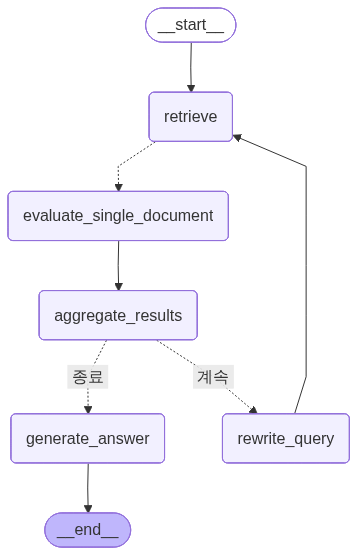

In [40]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(PersonalRagState)

workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("evaluate_single_document", evaluate_single_document)
workflow.add_node("aggregate_results", aggregate_results)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)

workflow.add_edge(START, "retrieve")

# 조건부 엣지로 병렬 처리 설정
workflow.add_conditional_edges(
    "retrieve",  # 문서 검색 완료 후
    create_evaluation_workers,  # 조건부 엣지 함수
    ["evaluate_single_document"]  # 병렬 워커 노드
)

workflow.add_edge("evaluate_single_document", "aggregate_results")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "aggregate_results",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
personal_law_agent = workflow.compile()

# 그래프 시각화
display(Image(personal_law_agent.get_graph().draw_mermaid_png()))

In [41]:
inputs = {"question": "개인정보 처리에 대한 동의를 받을 때 주의해야 할 점은 무엇인가요?"}
for output in personal_law_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---개인정보보호법 문서 검색---
---개인정보보호법 관련 4개 문서에 대한 평가 병렬 워커 생성---
"Node 'retrieve':"
("Value: {'documents': [Document(id='a593ca38-e0d2-4ada-bff2-1c6d029a35e5', "
 "metadata={'chapter': '제3장 개인정보의 처리\\n         제1절 개인정보의 수집, 이용, 제공 등', "
 "'name': '개인정보 보호법', 'source': 'data/personal_info_law.pdf'}, "
 "page_content='<출처>\\n다음 조항은 **개인정보 보호법** 본문의 **제3장 개인정보의 처리\\n         제1절 "
 '개인정보의 수집, 이용, 제공 등**에서 발췌한 내용입니다.\\n</출처>\\n\\n<법률조항>\\n제22조(동의를 받는 방법) ① '
 '개인정보처리자는 이 법에 따른 개인정보의 처리에 대하여 정보주체(제22조의2제1항에\\n따른 법정대리인을 포함한다. 이하 이 조에서 '
 '같다)의 동의를 받을 때에는 각각의 동의 사항을 구분하여 정보주체가\\n이를 명확하게 인지할 수 있도록 알리고 동의를 받아야 한다. 이 '
 '경우 다음 각 호의 경우에는 동의 사항을 구분하여\\n각각 동의를 받아야 한다. <개정 2017. 4. 18., 2023. 3. '
 '14.>\\n1. 제15조제1항제1호에 따라 동의를 받는 경우\\n2. 제17조제1항제1호에 따라 동의를 받는 '
 '경우\\n\\x0c\\n3. 제18조제2항제1호에 따라 동의를 받는 경우\\n4. 제19조제1호에 따라 동의를 받는 경우\\n5. '
 '제23조제1항제1호에 따라 동의를 받는 경우\\n6. 제24조제1항제1호에 따라 동의를 받는 경우\\n7. 재화나 서비스를 홍보하거나 '
 '판매를 권유하기 위하여 개인정보의 처리에 대한 동의를 받으려는 경우\\n8. 그 밖에 정보주체를 보호하기 위하여 동의 사항을 구분하여 '
 '동의를 받아야 할 

In [42]:
# 마크다운 형식을 노트북에 표시
from IPython.display import Markdown
display(Markdown(value['node_answer']))

```markdown
# 개인정보 처리에 대한 동의를 받을 때 주의해야 할 점

## 1. 질문에 대한 직접적인 답변
개인정보 처리에 대한 동의를 받을 때는 동의 사항을 각각 구분하여 정보주체가 명확히 인지할 수 있도록 알리고, 수집·이용 목적, 수집하려는 개인정보 항목, 보유 및 이용 기간, 동의 거부 권리 및 거부 시 불이익 내용을 명확히 안내해야 합니다. 또한, 동의는 서면 등 알아보기 쉽게 해야 하며, 선택적 동의를 거부한다고 해서 재화나 서비스 제공을 거부해서는 안 됩니다. 동의 철회가 가능함을 알리고, 철회 시 개인정보처리자가 신속히 필요한 조치를 해야 한다는 점도 주의해야 합니다.

## 2. 관련 법률 조항 및 해석
- **개인정보 보호법 제15조(개인정보의 수집ㆍ이용) ①, ②항**  
  개인정보처리자는 개인정보 수집 시 수집·이용 목적, 수집하려는 개인정보 항목, 보유 및 이용 기간, 동의 거부 권리 및 거부 시 불이익 내용을 정보주체에게 알려야 하며, 동의를 받아야 한다. (출처: 개인정보 보호법 제15조 ①, ②항)

- **개인정보 보호법 제22조(동의를 받는 방법) 제1항, 제2항, 제3항, 제5항**  
  동의는 각각의 동의 사항을 구분하여 명확히 알리고, 서면 동의 시 중요한 내용을 알아보기 쉽게 표시해야 한다. 동의 없이 처리 가능한 개인정보 항목과 법적 근거도 알려야 하며, 선택적 동의를 거부해도 서비스 제공을 거부해서는 안 된다. (출처: 개인정보 보호법 제22조 제1, 2, 3, 5항)

- **개인정보 보호법 제37조(동의 철회 등) 제1항, 제2항, 제3항**  
  정보주체는 언제든지 동의를 철회할 수 있고, 개인정보처리자는 동의 철회 시 지체 없이 개인정보를 파기하거나 처리 정지 등의 조치를 해야 한다. 다만 법률상 의무 준수 등 예외가 있을 경우 거절할 수 있으며, 거절 사유를 즉시 알려야 한다. (출처: 개인정보 보호법 제37조)

- **개인정보 보호법 제20조 제1항**  
  개인정보를 정보주체 이외로부터 수집할 때는 수집 출처, 처리 목적, 처리 정지 요구 및 동의 철회 권리 등을 알려야 한다. (출처: 개인정보 보호법 제20조 제1항)

## 3. 추가 설명 또는 예시
- **구분된 동의**: 예를 들어, 마케팅 활용 동의와 서비스 제공을 위한 개인정보 수집 동의를 별도로 받아야 하며, 각각의 목적과 내용을 명확히 설명해야 합니다.  
- **선택적 동의와 필수 동의 구분**: 필수 동의는 서비스 제공에 꼭 필요한 개인정보에 대해 받고, 마케팅 등 부가적인 목적은 선택적 동의로 구분하여 동의하지 않아도 서비스 이용에 불이익이 없도록 해야 합니다.  
- **동의 철회 절차 안내**: 동의 철회 방법과 절차를 쉽게 알 수 있도록 안내하고, 철회 시 개인정보처리자가 즉시 조치하는 체계를 갖추는 것이 중요합니다.

## 4. 결론 및 요약
개인정보 처리 동의는 정보주체가 각 동의 사항을 명확히 이해할 수 있도록 구분하여 알리고, 수집 목적, 항목, 보유 기간, 동의 거부 권리 및 불이익 내용을 명확히 안내해야 합니다. 동의는 서면 등 알아보기 쉽게 받아야 하며, 선택적 동의를 거부해도 서비스 제공을 거부해서는 안 됩니다. 또한, 동의 철회 권리를 보장하고, 철회 시 개인정보처리자가 신속히 필요한 조치를 해야 합니다. 이러한 절차를 준수함으로써 개인정보 보호법을 충실히 이행할 수 있습니다.

---

**참고 문헌**  
- 개인정보 보호법 제15조, 제20조, 제22조, 제37조 (출처: 대한민국 개인정보 보호법)
```

`(2) 근로기준법 RAG 에이전트`

In [43]:
# 근로기준법
class LaborRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문 
    extracted_info: Annotated[List[InformationStrip], operator.add]  # 병렬 워커들로부터 여러 정보 조각을 수집
    processed_info: List[InformationStrip]  # 후처리된 결과용 
    node_answer: Optional[str]

In [44]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal, List
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_transformers import EmbeddingsRedundantFilter
from langchain_core.documents import Document

def retrieve_documents(state: LaborRagState) -> LaborRagState:
    print("---근로기준법 문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = labor_law_search.invoke(query)
    return {"documents": docs}


def create_evaluation_workers(state: LaborRagState):
    """각 문서에 대해 평가 작업을 수행하는 병렬 워커를 생성하는 조건부 엣지 함수"""
    print(f"---근로기준법 관련 {len(state['documents'])}개 문서에 대한 평가 병렬 워커 생성---")

    # 각 문서에 대해 Send 객체를 생성하여 병렬 처리
    return [
        Send("evaluate_single_document", {
            "document": doc.page_content,
            "question": state["question"]
        })
        for doc in state["documents"]
    ]


def evaluate_single_document(state: DocumentWorkerState) -> LaborRagState:
    """단일 문서를 처리하는 워커 함수"""
    print(f"---근로기준법 단일 문서 처리 중 (길이: {len(state['document'])}...)---")

    # 프롬프트 템플릿 정의
    extract_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 근로기준법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
        각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
        1. 질문과의 관련성
        2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
        추출 형식:
        1. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        2. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        ...  
                    
        마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n<문서 내용>\n{document_content}\n</문서 내용>")
    ])

    # LLM 호출
    extract_llm = llm.with_structured_output(ExtractedInformation)  
    try:    
        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=state["document"],
            user_feedback=[("system", f"정보를 추출할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
        ))

        # 품질 필터링
        if extracted_data.query_relevance < 0.8:
            print(f"문서 관련성이 낮음: {extracted_data.query_relevance}")
            return {"extracted_info": []}

        # 고품질 정보만 필터링
        high_quality_strips = [
            strip for strip in extracted_data.strips
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7
        ]
        
        print(f"고품질 정보 {len(high_quality_strips)}개 추출됨")
        return {"extracted_info": high_quality_strips}
    
    except Exception as e:
        print(f"문서 처리 중 오류 발생: {e}")
        return {"extracted_info": []}
    


# 임베딩 모델
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# LangChain의 EmbeddingsRedundantFilter 초기화
redundant_filter = EmbeddingsRedundantFilter(
    embeddings=embeddings,
    similarity_threshold=0.85,  # 85% 이상 유사하면 중복으로 판단
)

def remove_semantic_duplicates(info_list: List[InformationStrip], 
                              similarity_threshold: float = 0.85) -> List[InformationStrip]:
    """LangChain EmbeddingsRedundantFilter를 사용한 의미적 중복 제거"""
    if not info_list:
        return []
    
    if len(info_list) == 1:
        return info_list
    
    try:
        # InformationStrip을 Document로 변환
        documents = []
        for i, info in enumerate(info_list):
            doc = Document(
                page_content=info.content,
                metadata={
                    "index": i,
                    "source": info.source,
                    "relevance_score": info.relevance_score,
                    "faithfulness_score": info.faithfulness_score
                }
            )
            documents.append(doc)
        
        # 임계값이 기본값과 다르면 새로운 필터 생성
        if similarity_threshold != 0.85:
            filter_instance = EmbeddingsRedundantFilter(
                embeddings=embeddings,
                similarity_threshold=similarity_threshold,
            )
        else:
            filter_instance = redundant_filter
        
        # 중복 제거 수행
        unique_documents = filter_instance.transform_documents(documents)
        
        # Document를 다시 InformationStrip으로 변환
        unique_info = []
        for doc in unique_documents:
            original_index = doc.metadata["index"]
            unique_info.append(info_list[original_index])
        
        # 품질 점수 순으로 정렬
        unique_info.sort(
            key=lambda x: (x.relevance_score + x.faithfulness_score) / 2, 
            reverse=True
        )
        
        print(f"EmbeddingsRedundantFilter 중복 제거: {len(info_list)} → {len(unique_info)}개")
        return unique_info
        
    except Exception as e:
        print(f"EmbeddingsRedundantFilter 처리 중 오류: {e}")
        return info_list


def aggregate_results(state: LaborRagState) -> LaborRagState:
    """병렬 처리된 결과를 집계하는 함수"""
    print(f"---근로기준법 관련 총 {len(state['extracted_info'])}개의 정보 조각 집계---")
    
    if not state["extracted_info"]:
        return {
            "num_generations": state.get("num_generations", 0) + 1,
            "processed_info": []
        }
    
    # 1. LangChain EmbeddingsRedundantFilter를 사용한 의미적 중복 제거
    unique_info = remove_semantic_duplicates(
        state["extracted_info"], 
        similarity_threshold=0.85  # 85% 이상 유사하면 중복으로 판단
    )
    
    # 2. 품질 점수에 따른 정렬
    sorted_info = sorted(
        unique_info, 
        key=lambda x: (x.relevance_score + x.faithfulness_score) / 2, 
        reverse=True
    )
    
    # 3. 상위 N개만 선택 
    top_info = sorted_info[:10]  # 상위 10개만 유지
    
    print(f"최종 결과: {len(state['extracted_info'])} → {len(unique_info)}  → {len(top_info)}개")
    
    # 중요: extracted_info 키를 반환하지 않음 (reducer 중복 방지)
    return {
        "num_generations": state.get("num_generations", 0) + 1,
        "processed_info": top_info  # 후처리된 결과
    }


def rewrite_query(state: LaborRagState) -> LaborRagState:
    print("---근로기준법 쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 근로기준법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 근로기준법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<원래 질문>\n{question}\n</원래 질문>\n\n<추출된 정보>\n{processed_info}\n</추출된 정보>\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    processed_info_str = "\n".join([strip.content for strip in state["processed_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"쿼리를 재작성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))
    
    return {"rewritten_query": response.question_refined}


def generate_node_answer(state: LaborRagState) -> LaborRagState:
    print("---근로기준법 답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 근로기준법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 근로기준법 제15조)"""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n\n<추출된 정보>\n{processed_info}\n</추출된 정보>\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    processed_info_str = "\n---\n".join([f"**내용**: {strip.content}\n**출처**: {strip.source}\n**관련성**: {strip.relevance_score}\n**충실성**: {strip.faithfulness_score}" for strip in state["processed_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: LaborRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["processed_info"]) > 0:
        return "종료"
    return "계속"

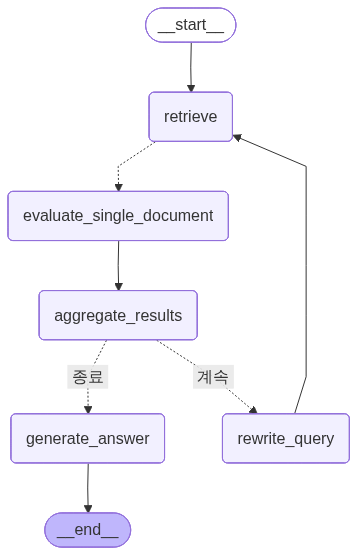

In [45]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(LaborRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("evaluate_single_document", evaluate_single_document)
workflow.add_node("aggregate_results", aggregate_results)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)  

workflow.add_edge(START, "retrieve")

# 조건부 엣지로 병렬 처리 설정
workflow.add_conditional_edges(
    "retrieve",  # 문서 검색 완료 후
    create_evaluation_workers,  # 조건부 엣지 함수
    ["evaluate_single_document"]  # 병렬 워커 노드
)

workflow.add_edge("evaluate_single_document", "aggregate_results")
workflow.add_conditional_edges(
    "aggregate_results",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
labor_law_agent = workflow.compile()

# 그래프 시각화
display(Image(labor_law_agent.get_graph().draw_mermaid_png()))

In [46]:
inputs = {"question": "근로계약 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in labor_law_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---근로기준법 문서 검색---
---근로기준법 관련 4개 문서에 대한 평가 병렬 워커 생성---
"Node 'retrieve':"
("Value: {'documents': [Document(id='9a08ba9e-f5ab-4d9c-89d8-e2b490ca9000', "
 "metadata={'source': 'data/labor_law.pdf', 'chapter': '제5장 여성과 소년', 'name': "
 "'근로기준법'}, page_content='<출처>\\n다음 조항은 **근로기준법** 본문의 **제5장 "
 '여성과 소년**에서 발췌한 내용입니다.\\n</출처>\\n\\n<법률조항>\\n제67조(근로계약) ① 친권자나 후견인은 미성년자의 '
 '근로계약을 대리할 수 없다.\\n② 친권자, 후견인 또는 고용노동부장관은 근로계약이 미성년자에게 불리하다고 인정하는 경우에는 이를 해지할 '
 '수\\n있다.<개정 2010. 6. 4.>\\n③ 사용자는 18세 미만인 사람과 근로계약을 체결하는 경우에는 제17조에 따른 근로조건을 '
 '서면(「전자문서 및 전\\n자거래 기본법」 제2조제1호에 따른 전자문서를 포함한다)으로 명시하여 교부하여야 한다.<신설 2007. 7. '
 "27., 2020.\\n5. 26., 2021. 1. 5.>\\n</법률조항>'), "
 "Document(id='2038ec82-b471-4da4-871a-c25b43b78d2c', metadata={'chapter': "
 "'제1장 총칙', 'name': '근로기준법', 'source': 'data/labor_law.pdf'}, "
 "page_content='<출처>\\n다음 조항은 **근로기준법** 본문의 **제1장 총칙**에서 발췌한 "
 '내용입니다.\\n</출처>\\n\\n<법률조항>\\n제5조(근로조건의 준수) 근로자와 사용자는 각자가 단체협약, 취업규칙과 근로계약을 '
 "지키고 성실하게 이행할 의무가\\n있다

In [47]:
# 마크다운 형식으로 출력
from IPython.display import Markdown
display(Markdown(value['node_answer']))

```markdown
### 1. 질문에 대한 직접적인 답변
근로계약 체결 시 주의해야 할 점은 다음과 같습니다.  
- 근로조건을 반드시 서면 또는 전자문서로 명시하여 교부해야 하며, 특히 18세 미만 근로자와 계약할 때는 더욱 엄격히 준수해야 합니다.  
- 근로조건은 근로기준법에서 정한 기준에 미치지 못하면 무효가 되므로, 법정 기준 이상으로 계약 내용을 작성해야 합니다.  
- 근로자와 사용자는 단체협약, 취업규칙, 근로계약을 성실히 준수하고 이행할 의무가 있습니다.  
- 미성년자의 경우 친권자나 후견인이 근로계약을 대리할 수 없으며, 불리한 계약은 친권자, 후견인 또는 고용노동부장관이 해지할 수 있습니다.  
- 계약기간은 원칙적으로 1년을 초과할 수 없으나, 기간을 정하지 않은 계약이나 일정 사업 완료 기간 계약은 예외입니다.

### 2. 관련 법률 조항 및 해석
- **근로기준법 제5장 여성과 소년 제67조**  
  18세 미만 근로자와 계약 시 근로조건을 서면 또는 전자문서로 명시하여 교부해야 하며, 친권자나 후견인이 대리할 수 없습니다. 또한 불리한 계약은 해지할 수 있습니다. (출처: 근로기준법 제5장 여성과 소년 제67조)  
- **근로기준법 제1장 총칙 제5조**  
  근로자와 사용자는 단체협약, 취업규칙, 근로계약을 준수하고 성실히 이행할 의무가 있습니다. (출처: 근로기준법 제1장 총칙 제5조)  
- **근로기준법 제2장 근로계약 제15조**  
  근로조건이 법정 기준에 미치지 못하면 무효이며, 무효 부분은 법정 기준에 따라 대체됩니다. (출처: 근로기준법 제2장 근로계약 제15조)  
- **근로기준법 제2장 근로계약 제16조**  
  계약기간은 1년을 초과할 수 없으나, 기간을 정하지 않은 계약과 일정 사업 완료 기간 계약은 예외입니다. (출처: 근로기준법 제2장 근로계약 제16조)

### 3. 추가 설명 또는 예시
- 예를 들어, 18세 미만 청소년을 채용할 경우 근로시간, 휴게시간, 임금 등 근로조건을 반드시 서면으로 명확히 하여 교부해야 하며, 이를 위반하면 법적 제재를 받을 수 있습니다.  
- 계약서에 명시된 임금이 최저임금 이하라면 그 부분은 무효가 되고, 최저임금 기준으로 자동 대체됩니다.  
- 계약기간을 2년으로 정하는 것은 원칙적으로 불가능하며, 1년 이내로 계약하거나 무기계약으로 전환하는 방식을 고려해야 합니다.

### 4. 결론 및 요약
근로계약 체결 시에는 근로조건을 명확히 서면 또는 전자문서로 명시하고, 법정 기준을 반드시 준수해야 합니다. 특히 미성년자 근로계약은 별도의 규정을 엄격히 따라야 하며, 계약기간도 법적 제한을 받습니다. 근로자와 사용자는 계약 내용을 성실히 이행할 의무가 있으므로, 계약 체결 전 관련 법률을 충분히 검토하는 것이 중요합니다.  
(출처: 근로기준법 제1장 총칙 제5조, 제2장 근로계약 제15조·제16조, 제5장 여성과 소년 제67조)
```

`(3) 주택임대차보호법 RAG 에이전트`

In [48]:
# 주택임대차보호법
class HousingRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문 
    extracted_info: Annotated[List[InformationStrip], operator.add]  # 병렬 워커들로부터 여러 정보 조각을 수집
    processed_info: List[InformationStrip]  # 후처리된 결과용 
    node_answer: Optional[str]

In [49]:
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send

def retrieve_documents(state: HousingRagState) -> HousingRagState:
    print("---주택임대차보호법 문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = housing_law_search.invoke(query)
    return {"documents": docs}

def create_evaluation_workers(state: HousingRagState):
    """각 문서에 대해 평가 작업을 수행하는 병렬 워커를 생성하는 조건부 엣지 함수"""
    print(f"---주택임대차보호법 관련 {len(state['documents'])}개 문서에 대한 평가 병렬 워커 생성---")

    # 각 문서에 대해 Send 객체를 생성하여 병렬 처리
    return [
        Send("evaluate_single_document", {
            "document": doc.page_content,
            "question": state["question"],
            "user_feedback": state.get("user_feedback", ""),  # 사용자 피드백이 있는 경우 전달
        })
        for doc in state["documents"]
    ]

def evaluate_single_document(state: DocumentWorkerState) -> HousingRagState:
    """단일 문서를 처리하는 워커 함수"""
    print(f"---주택임대차보호법 관련 단일 문서 처리 중 (길이: {len(state['document'])}...)---")
    
    # 프롬프트 템플릿 정의
    extract_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 주택임대차보호법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
        각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
        1. 질문과의 관련성
        2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
        
        추출 형식:
        1. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        2. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        ...
        
        마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n\n<문서 내용>\n{document_content}\n</문서 내용>")
    ])

    # LLM 호출 
    extract_llm = llm.with_structured_output(ExtractedInformation)
    
    try:
        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=state["document"],
            user_feedback=[("system", f"정보를 추출할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
        ))

        # 품질 필터링
        if extracted_data.query_relevance < 0.8:
            print(f"문서 관련성이 낮음: {extracted_data.query_relevance}")
            return {"extracted_info": []}

        # 고품질 정보만 필터링
        high_quality_strips = [
            strip for strip in extracted_data.strips
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7
        ]
        
        print(f"고품질 정보 {len(high_quality_strips)}개 추출됨")
        return {"extracted_info": high_quality_strips}
        
    except Exception as e:
        print(f"문서 처리 중 오류 발생: {e}")
        return {"extracted_info": []}

def aggregate_results(state: HousingRagState) -> HousingRagState:
    """병렬 처리된 결과를 집계하는 함수"""
    print(f"---주택임대차보호법 관련 총 {len(state['extracted_info'])}개의 정보 조각 집계---")
    
    if not state["extracted_info"]:
        return {
            "num_generations": state.get("num_generations", 0) + 1,
            "processed_info": []
        }
    
    # 1. LangChain EmbeddingsRedundantFilter를 사용한 의미적 중복 제거
    unique_info = remove_semantic_duplicates(
        state["extracted_info"], 
        similarity_threshold=0.85  # 85% 이상 유사하면 중복으로 판단
    )
    
    # 2. 품질 점수에 따른 정렬
    sorted_info = sorted(
        unique_info, 
        key=lambda x: (x.relevance_score + x.faithfulness_score) / 2, 
        reverse=True
    )
    
    # 3. 상위 N개만 선택 
    top_info = sorted_info[:10]  # 상위 10개만 유지
    
    print(f"최종 결과: {len(state['extracted_info'])} → {len(unique_info)}  → {len(top_info)}개")
    
    # 중요: extracted_info 키를 반환하지 않음 (reducer 중복 방지)
    return {
        "num_generations": state.get("num_generations", 0) + 1,
        "processed_info": top_info  # 후처리된 결과
    }

In [50]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def rewrite_query(state: HousingRagState) -> HousingRagState:
    print("---주택임대차보호법 쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 주택임대차보호법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 주택임대차보호법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<원래 질문>\n{question}\n</원래 질문>\n\n<추출된 정보>\n{processed_info}\n</추출된 정보>\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    processed_info_str = "\n".join([strip.content for strip in state["processed_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"쿼리를 재작성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))

    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: HousingRagState) -> HousingRagState:
    print("---주택임대차보호법 답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 주택임대차보호법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 주택임대차보호법 제15조)"""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n\n<추출된 정보>\n{processed_info}\n</추출된 정보>\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    processed_info_str = "\n---\n".join([f"**내용**: {strip.content}\n**출처**: {strip.source}\n**관련성**: {strip.relevance_score}\n**충실성**: {strip.faithfulness_score}" for strip in state["processed_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: HousingRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["processed_info"]) > 0:
        return "종료"
    return "계속"

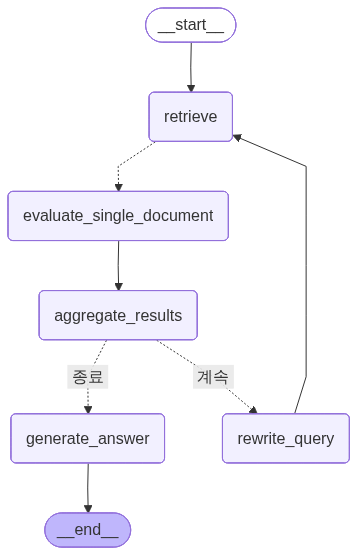

In [51]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(HousingRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("evaluate_single_document", evaluate_single_document)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)
workflow.add_node("aggregate_results", aggregate_results)

workflow.add_edge(START, "retrieve")
# 조건부 엣지로 병렬 처리 설정
workflow.add_conditional_edges(
    "retrieve",  # 문서 검색 완료 후
    create_evaluation_workers,  # 조건부 엣지 함수
    ["evaluate_single_document"]  # 병렬 워커 노드
)
workflow.add_edge("evaluate_single_document", "aggregate_results")
workflow.add_conditional_edges(
    "aggregate_results",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)

workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
housing_law_agent = workflow.compile()

# 그래프 시각화
display(Image(housing_law_agent.get_graph().draw_mermaid_png()))

In [52]:
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in housing_law_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---주택임대차보호법 문서 검색---
---주택임대차보호법 관련 4개 문서에 대한 평가 병렬 워커 생성---
"Node 'retrieve':"
("Value: {'documents': [Document(id='62e60148-3353-4134-8937-cc8deb5cf727', "
 "metadata={'name': '주택임대차보호법', 'source': "
 "'data/housing_leasing_law.pdf'}, page_content='<출처>\\n다음 조항은 "
 '**주택임대차보호법**에서 발췌한 내용입니다.\\n</출처>\\n\\n<법률조항>\\n제3조의7(임대인의 정보 제시 '
 '의무) 임대차계약을 체결할 때 임대인은 다음 각 호의 사항을 임차인에게 제시하여야 한\\n다.\\n1. 제3조의6제3항에 따른 해당 '
 '주택의 확정일자 부여일, 차임 및 보증금 등 정보. 다만, 임대인이 임대차계약을 체결\\n하기 전에 제3조의6제4항에 따라 동의함으로써 '
 '이를 갈음할 수 있다.\\n2. 「국세징수법」 제108조에 따른 납세증명서 및 「지방세징수법」 제5조제2항에 따른 납세증명서. 다만, '
 '임대인이 임\\n대차계약을 체결하기 전에 「국세징수법」 제109조제1항에 따른 미납국세와 체납액의 열람 및 「지방세징수법」 '
 '제\\n6조제1항에 따른 미납지방세의 열람에 각각 동의함으로써 이를 갈음할 수 있다.\\n[본조신설 2023. 4. '
 "18.]\\n</법률조항>'), Document(id='86fc82d5-dc32-4d37-8129-bbd4da2f0c61', "
 "metadata={'name': '주택임대차보호법', 'source': "
 "'data/housing_leasing_law.pdf'}, page_content='<출처>\\n다음 조항은 "
 '**주택임대차보호법**에서 발췌한 내용입니다.\\n</출처>\\n\\n<법률조항>\\n제30조(주택임

In [53]:
# 마크다운 형식으로 출력
from IPython.display import Markdown
display(Markdown(value['node_answer']))

```markdown
### 1. 질문에 대한 직접적인 답변
대리인과 아파트 임대차 계약을 체결할 때는 임대차 계약의 갱신 조건과 통지 기간을 반드시 확인하고, 임대인이 임차인에게 확정일자 부여일, 차임, 보증금 등의 중요한 정보를 명확히 제시했는지 주의해야 합니다. 또한, 임대차 계약 갱신 거절이나 조건 변경 통지가 적법한 기간 내에 이루어졌는지 확인해야 하며, 임차인의 동의가 있을 경우 납세증명서 제시를 갈음할 수 있는 점도 고려해야 합니다.

### 2. 관련 법률 조항 및 해석
- **주택임대차보호법 제3조의7**  
  임대인은 임대차계약 체결 시 임차인에게 확정일자 부여일, 차임 및 보증금 등의 정보를 제공해야 하며, 임차인의 동의를 받으면 납세증명서 제시를 갈음할 수 있습니다.  
  (출처: 주택임대차보호법 제3조의7)

- **주택임대차보호법 제6조**  
  임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 하며, 이를 하지 않으면 기존 조건으로 자동 갱신됩니다.  
  임차인이 2개월 전까지 갱신 거절 통지를 하지 않으면 계약은 동일 조건으로 자동 갱신됩니다.  
  단, 임차인이 2기 차임액에 달하는 연체를 하거나 임차인 의무를 현저히 위반한 경우에는 갱신 규정이 적용되지 않습니다.  
  (출처: 주택임대차보호법 제6조)

### 3. 추가 설명 또는 예시
- **대리인 계약 시 주의점**  
  대리인이 계약을 체결하는 경우, 임대인과 임차인 간의 권리·의무가 동일하게 적용되므로 대리인의 권한 범위와 신분 확인이 중요합니다.  
- **갱신 통지 기간 준수**  
  예를 들어, 임대차 기간이 1월 1일에 종료된다면 임대인은 전년도 7월 1일부터 11월 30일 사이에 갱신 거절 또는 조건 변경 통지를 해야 하며, 이를 어길 경우 자동 갱신됩니다.  
- **확정일자 및 보증금 정보 제공**  
  임대인은 임차인에게 확정일자 부여일을 알려주어 임차인의 권리 보호를 돕고, 보증금 및 차임 내역을 명확히 해야 분쟁을 예방할 수 있습니다.

### 4. 결론 및 요약
대리인과 아파트 임대차 계약을 체결할 때는 임대인이 임차인에게 확정일자, 보증금, 차임 등의 정보를 명확히 제공했는지 확인하고, 임대차 계약 갱신과 관련한 통지 기간(임대차 종료 6개월 전부터 2개월 전까지)을 반드시 준수했는지 주의해야 합니다. 또한, 임차인의 동의를 받으면 납세증명서 제시를 갈음할 수 있으므로 이 점도 고려해야 하며, 임차인의 의무 위반이나 차임 연체 여부도 계약 갱신에 영향을 미칠 수 있음을 유념해야 합니다.  
(출처: 주택임대차보호법 제3조의7, 제6조)
```

`(4) 웹 검색 기반 RAG 에이전트`

In [54]:
# 웹 검색 도구 
class SearchRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문 
    extracted_info: Annotated[List[InformationStrip], operator.add]  # 병렬 워커들로부터 여러 정보 조각을 수집
    processed_info: List[InformationStrip]  # 후처리된 결과용 
    node_answer: Optional[str]

In [55]:
def retrieve_documents(state: SearchRagState) -> dict:
    """웹 문서 검색 함수"""
    print("---웹 문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = web_search.invoke(query)
    return {"documents": docs}

def create_evaluation_workers(state: SearchRagState):
    """각 웹 문서에 대해 평가 작업을 수행하는 병렬 워커를 생성하는 조건부 엣지 함수"""
    print(f"---{len(state['documents'])}개 웹 문서에 대한 평가 병렬 워커 생성---")

    # 각 문서에 대해 Send 객체를 생성하여 병렬 처리
    return [
        Send("evaluate_single_document", {
            "document": doc.page_content,
            "question": state["question"],
            "user_feedback": state.get("user_feedback", ""),  # 사용자 피드백이 있는 경우 전달
        })
        for doc in state["documents"]
    ]

def evaluate_single_document(state: DocumentWorkerState) -> dict:
    """단일 웹 문서를 처리하는 워커 함수"""
    print(f"---단일 웹 문서 처리 중 (길이: {len(state['document'][:100])}...)---")
    
    # 웹 검색에 특화된 프롬프트 템플릿
    extract_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 웹 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
        
        웹 정보 추출 시 주의사항:
        - 신뢰할 수 있는 정보인지 판단하세요
        - 날짜가 명시된 정보는 시기를 포함하여 추출하세요
        - 통계나 수치 정보는 정확히 추출하세요
        - 출처 URL이나 사이트 정보를 포함하세요
        
        각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
        1. 질문과의 관련성
        2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
        
        추출 형식:
        1. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        2. [추출된 정보]
        - 관련성 점수: [0-1 사이의 점수]
        - 충실성 점수: [0-1 사이의 점수]
        ...
        
        마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n<웹 문서 내용>\n{document_content}\n</웹 문서 내용>")
    ])

    extract_llm = llm.with_structured_output(ExtractedInformation)
    
    try:
        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=state["document"],
            user_feedback=[("system", f"정보를 추출할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
        ))

        # 웹 정보의 품질 필터링 (조금 더 엄격)
        if extracted_data.query_relevance < 0.7:  # 웹 정보는 노이즈가 많으므로
            print(f"웹 문서 관련성이 낮음: {extracted_data.query_relevance}")
            return {"extracted_info": []}

        # 고품질 정보만 필터링
        high_quality_strips = [
            strip for strip in extracted_data.strips
            if strip.relevance_score > 0.6 and strip.faithfulness_score > 0.6  # 웹 정보 특성상 조금 낮춤
        ]
        
        print(f"고품질 웹 정보 {len(high_quality_strips)}개 추출됨")
        return {"extracted_info": high_quality_strips}
        
    except Exception as e:
        print(f"웹 문서 처리 중 오류 발생: {e}")
        return {"extracted_info": []}

def aggregate_results(state: SearchRagState) -> dict:
    """병렬 처리된 웹 검색 결과를 집계하는 함수"""
    print(f"---총 {len(state['extracted_info'])}개의 웹 정보 조각 집계---")
    
    if not state["extracted_info"]:
        return {
            "num_generations": state.get("num_generations", 0) + 1,
            "processed_info": []
        }
    
    # 1. LangChain EmbeddingsRedundantFilter를 사용한 의미적 중복 제거
    unique_info = remove_semantic_duplicates(
        state["extracted_info"], 
        similarity_threshold=0.85  # 85% 이상 유사하면 중복으로 판단
    )
    
    # 2. 품질 점수에 따른 정렬
    sorted_info = sorted(
        unique_info, 
        key=lambda x: (x.relevance_score + x.faithfulness_score) / 2, 
        reverse=True
    )
    
    # 3. 상위 N개만 선택 
    top_info = sorted_info[:10]  # 상위 10개만 유지
    
    print(f"최종 결과: {len(state['extracted_info'])} → {len(unique_info)}  → {len(top_info)}개")
    
    # 중요: extracted_info 키를 반환하지 않음 (reducer 중복 방지)
    return {
        "num_generations": state.get("num_generations", 0) + 1,
        "processed_info": top_info  # 후처리된 결과
    }

def rewrite_query(state: SearchRagState) -> dict:
    """웹 검색 쿼리 재작성 함수"""
    print("---웹 검색 쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 원래 질문과 추출된 웹 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        웹 검색 쿼리 개선 가이드라인:
        1. 원래 질문의 핵심 키워드 유지
        2. 추출된 정보에서 부족한 부분 파악
        3. 시간적 맥락이 중요한 경우 연도 추가
        4. 구체적인 용어나 전문 용어 활용
        5. 검색 엔진 최적화를 고려한 키워드 조합

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-15 단어 사이).
        3. 질문과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<원래 질문>\n{question}\n</원래 질문>\n<웹 문서 내용>\n{processed_info}\n<</웹 문서 내용>\n\n위 지침에 따라 개선된 웹 검색 쿼리를 작성해주세요.")
    ])

    processed_info_str = "\n".join([
        f"- {strip.content} (출처: {strip.source})" 
        for strip in state["processed_info"]
    ])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"쿼리를 재작성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))
    
    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: SearchRagState) -> dict:
    """웹 검색 결과 기반 답변 생성 함수"""
    print("---웹 검색 기반 답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 질문과 웹에서 추출된 정보를 바탕으로 신뢰할 수 있는 답변을 생성해주세요. 
        
        웹 정보 기반 답변 작성 가이드라인:
        - 여러 출처의 정보를 종합하여 균형잡힌 답변 제공
        - 정보의 신뢰도와 출처를 명확히 표시
        - 상충되는 정보가 있다면 명시
        - 정보의 시점이나 업데이트 날짜 고려
        - 추가 검증이 필요한 정보는 명시
        
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변 요약
        2. 상세 설명 (웹 정보 기반)
        3. 관련 출처 및 링크
        4. 주의사항 또는 추가 고려사항 (있는 경우)
        5. 결론 및 요약
        
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 
        예: (출처: 네이버 뉴스, 2024.01.15) 또는 (출처: 위키피디아)"""),
        MessagesPlaceholder("user_feedback"),
        ("human", "<질문>\n{question}\n</질문>\n<웹에서 추출된 정보>\n{processed_info}\n</웹에서 추출된 정보>\n\n위 지침에 따라 신뢰할 수 있는 최종 답변을 작성해주세요.")
    ])

    # 웹 정보를 더 상세하게 포맷팅
    processed_info_str = "\n---\n".join([
        f"**내용**: {strip.content}\n"
        f"**출처**: {strip.source}\n"
        f"**신뢰도**: 관련성 {strip.relevance_score:.2f}, 충실성 {strip.faithfulness_score:.2f}"
        for strip in state["processed_info"]
    ])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        processed_info=processed_info_str,
        user_feedback=[("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{state.get('user_feedback', '')}</피드백>")] if "user_feedback" in state else []
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: SearchRagState) -> Literal["계속", "종료"]:
    """웹 검색 계속 여부 결정 함수"""
    print(f"현재 생성 횟수: {state['num_generations']}, 추출된 웹 정보 수: {len(state['processed_info'])}")
    
    # 웹 검색은 정보가 많으므로 조건을 조정
    if state["num_generations"] >= 2:  # 최대 2번 재시도
        return "종료"

    if len(state["processed_info"]) > 0:  # 웹 정보가 1개 이상이면 충분
        return "종료"

    return "계속"

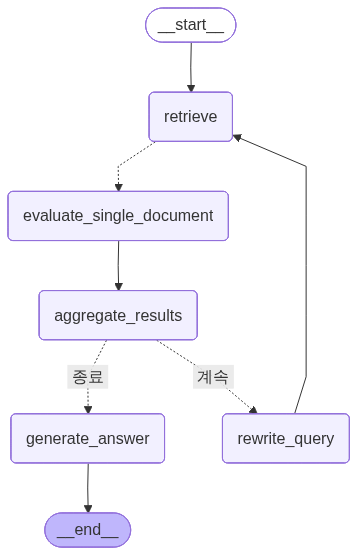

In [56]:
# 그래프 생성
workflow = StateGraph(SearchRagState)

# 노드 추가 
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("evaluate_single_document", evaluate_single_document)  # 병렬 워커 노드
workflow.add_node("aggregate_results", aggregate_results)                # 집계 노드
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)

# 엣지 추가 
workflow.add_edge(START, "retrieve")

# 조건부 엣지로 병렬 워커 생성 (retrieve → 병렬 워커들)
workflow.add_conditional_edges(
    "retrieve",  # 문서 검색 완료 후
    create_evaluation_workers,  # 각 문서에 대해 병렬 워커 생성
    ["evaluate_single_document"]  # 워커 노드들로 분기
)

# 병렬 처리 완료 후 집계 (워커들 → aggregate_results)
workflow.add_edge("evaluate_single_document", "aggregate_results")

# 집계 후 조건부 분기 (aggregate_results → 계속/종료)
workflow.add_conditional_edges(
    "aggregate_results",  # 집계 완료 후
    should_continue,      # 계속할지 결정
    {
        "계속": "rewrite_query",    # 정보 부족 시 쿼리 재작성
        "종료": "generate_answer"   # 충분한 정보 시 답변 생성
    }
)

# 재작성된 쿼리로 다시 검색
workflow.add_edge("rewrite_query", "retrieve")

# 최종 답변 생성 완료
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
search_web_agent = workflow.compile()

# 그래프 시각화
display(Image(search_web_agent.get_graph().draw_mermaid_png()))

In [59]:
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in search_web_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---웹 문서 검색---
---4개 웹 문서에 대한 평가 병렬 워커 생성---
"Node 'retrieve':"
("Value: {'documents': [Document(metadata={'source': 'web search', 'url': "
 "'https://blog.naver.com/funndtalk/223999606939'}, page_content='<Document "
 'href="https://blog.naver.com/funndtalk/223999606939"/>\\n대리인이계약을진행한다면 가장 먼저 '
 '확인해야할것은 위임장의 진정성입니다. 위임장에는 임대인과 대리인의 인적 사항, 계약 대상 부동산 주소, 위임 범위, 위임 기간 등이 '
 '명확하게 기재되어야 합니다. 단순히 부동산 관련 권한이라고 적힌 포괄적 표현보다는 전세계약 체결과 보증금 '
 "수령\\n</Document>'), Document(metadata={'source': 'web search', 'url': "
 "'https://blog.naver.com/sallimnea/223739183579'}, page_content='<Document "
 'href="https://blog.naver.com/sallimnea/223739183579"/>\\n부동산임대차계약에서 건물주 '
 '(임대인)가 아닌대리인과계약을진행하는 경우, 꼼꼼한 확인이 필수입니다. 대리인이 건물주의 배우자, 자녀, 혹은 가족이라 하더라도 '
 '법적으로는 대리계약에 해당하므로, 아래 사항들을 지키지 않으면 계약 무효나 금전적 손실 같은 문제가 발생할 수 '
 "있습니다\\n</Document>'), Document(metadata={'source': 'web search', 'url': "
 "'https://inlineskatestory.tistory.com/1338'}, page_content='<Document "
 'href="https://inlineskatestory.tistory.c

In [60]:
# 마크다운 형식으로 출력
from IPython.display import Markdown
display(Markdown(value['node_answer']))

```markdown
# 대리인과 아파트 임대차 계약 체결 시 주의사항

## 1. 질문에 대한 직접적인 답변 요약
대리인과 아파트 임대차 계약을 체결할 때는 위임장의 진정성 및 구체적 권한 확인, 임대인의 실제 소유 여부 확인, 대리인의 법적 책임과 권한 범위 명확화가 가장 중요합니다. 이를 소홀히 하면 계약 무효, 금전적 손실 등 법적 분쟁이 발생할 수 있으므로 꼼꼼한 검토가 필요합니다.

## 2. 상세 설명 (웹 정보 기반)
- **위임장 진정성 및 구체성 확인**  
  대리인이 임대차 계약을 체결할 때 가장 먼저 확인해야 할 것은 위임장의 진정성입니다. 위임장에는 임대인과 대리인의 인적 사항, 계약 대상 부동산 주소, 위임 범위, 위임 기간 등이 명확히 기재되어 있어야 하며, 단순히 ‘부동산 관련 권한’과 같은 포괄적 표현보다는 전세계약 체결, 보증금 수령 등 구체적인 권한이 명시되어야 합니다.  
  (출처: [네이버 블로그 funndtalk, 2023])

- **임대인의 실제 소유 여부 확인**  
  계약 상대방이 임대인인지, 즉 실제 부동산 소유자인지 반드시 확인해야 합니다. 대리인이더라도 임대인의 신분과 소유권이 명확하지 않으면 계약 자체가 무효가 될 위험이 있습니다.  
  (출처: [티스토리 inlineskatestory, 2023])

- **대리인의 법적 책임과 권한 범위**  
  대리인이 건물주의 가족이라도 법적으로 대리계약에 해당하며, 대리인은 계약 체결 시 책임 있는 자세로 임해야 합니다. 계약 후 발생하는 문제에 대해 대리인도 일정 부분 책임을 질 수 있으므로, 대리인의 권한 범위와 책임 소재를 명확히 해야 합니다.  
  (출처: [lawmen.co.kr, 2023], [네이버 블로그 sallimnea, 2023])

- **계약 무효 및 금전적 손실 방지**  
  위임장이나 임대인 확인이 부실할 경우 계약 무효, 보증금 반환 문제, 금전적 손실 등 법적 분쟁이 발생할 수 있으므로, 계약 전 꼼꼼한 서류 검토와 신분 확인이 필수입니다.  
  (출처: [네이버 블로그 sallimnea, 2023])

## 3. 관련 출처 및 링크
- [네이버 블로그 funndtalk - 대리인 임대차 계약 시 위임장 확인](https://blog.naver.com/funndtalk/223999606939)  
- [네이버 블로그 sallimnea - 대리인과 계약 시 주의사항](https://blog.naver.com/sallimnea/223739183579)  
- [티스토리 inlineskatestory - 임대인 신분 확인 중요성](https://inlineskatestory.tistory.com/1338)  
- [lawmen.co.kr - 전세계약 대리인 책임](https://lawmen.co.kr/%EC%A0%84%EC%84%B8%EA%B3%84%EC%95%BD-%EB%8C%80%EB%A6%AC%EC%9D%B8-%EA%BC%AD-%EC%95%8C%EC%95%84%EC%95%BC-%ED%95%A0-5%EA%B0%80%EC%A7%80-%EC%A3%BC%EC%9D%98%EC%82%AC%ED%95%AD/)

## 4. 주의사항 또는 추가 고려사항
- 위임장 위조나 허위 작성 사례가 있으므로, 위임장 진위 여부를 공증받거나 임대인과 직접 연락하여 확인하는 것이 안전합니다.  
- 대리인의 권한 범위가 불명확하면 계약 후 분쟁이 발생할 수 있으므로, 계약서에 대리인 권한과 책임을 명확히 기재하는 것이 좋습니다.  
- 임대인의 신분증 및 등기부등본 등 소유권 증명 서류를 반드시 확인해야 하며, 필요 시 부동산 전문가나 법률 전문가의 도움을 받는 것이 권장됩니다.

## 5. 결론 및 요약
대리인과 아파트 임대차 계약을 체결할 때는 위임장의 진정성과 구체적 권한, 임대인의 실제 소유 여부, 대리인의 법적 책임을 꼼꼼히 확인해야 합니다. 이를 통해 계약 무효나 금전적 손실 등 위험을 최소화할 수 있으며, 필요 시 전문가의 도움을 받아 계약 절차를 진행하는 것이 안전합니다.

---
*본 답변은 2023년 기준 최신 웹 정보를 종합하여 작성되었습니다.*
```

### 4-2. 질문 라우팅 
- 사용자의 질문을 분석하여 적절한 에이전트를 선택 (Adaptive RAG 적용)

In [61]:
from typing import Annotated
from operator import add

# 딕셔서리 병합을 위한 사용자 정의 리듀서 
def merge_agent_responses(left: dict, right: dict) -> dict:
    """에이전트 응답들을 병합하는 리듀서"""
    if left is None:
        left = {}
    if right is None:
        right = {}
    
    # 딕셔너리 병합
    merged = left.copy()
    merged.update(right)
    return merged

# 상태 정의
class ResearchAgentState(TypedDict):
    question: str
    answers: Annotated[List[str], add]  # 각 에이전트의 답변들
    agent_responses: Annotated[dict, merge_agent_responses]  # 병렬 처리 지원 리듀서
    final_answer: str
    datasources: List[str]
    evaluation_report: Optional[dict]
    iteration_count: Optional[int]
    user_decision: Literal["continue", "stop"]  # 사용자 결정 (계속/종료)
    user_feedback: Optional[str]  # 사용자 피드백

In [62]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field

# 라우팅 모델 정의
class ToolSelector(BaseModel):
    """Routes the user question to the most appropriate tool."""
    tool: Literal["search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"] = Field(
        description="Select one of the tools, based on the user's question.",
    )

class ToolSelectors(BaseModel):
    """Select the appropriate tools that are suitable for the user question."""
    tools: List[ToolSelector] = Field(
        description="Select one or more tools, based on the user's question.",
    )

# 라우팅 시스템
structured_llm_tool_selector = llm.with_structured_output(ToolSelectors)

# 라우팅 시스템 프롬프트
system = dedent("""You are an AI assistant specializing in routing user questions to the appropriate tools.
Use the following guidelines to select the most suitable tool(s):

## 법률 관련 도구 (Law-specific Tools)
- **search_personal**: 개인정보 보호법의 구체적인 조항, 법적 규정, 의무사항, 처벌 규정 등에 대한 질문
- **search_labor**: 근로기준법의 구체적인 조항, 근로 조건, 임금, 휴가, 해고 등 법적 규정에 대한 질문  
- **search_housing**: 주택임대차보호법의 구체적인 조항, 임대차 계약, 보증금, 임차인 권리 등에 대한 질문

## 웹 검색 도구 (Web Search Tool)
**search_web**을 사용하는 경우:
- 최신 정보나 실시간 데이터가 필요한 질문
- 현재 뉴스, 트렌드, 최근 사건에 대한 질문
- 법률 관련이지만 구체적인 조항보다는 현실적 적용 사례나 판례가 필요한 경우
- 통계, 시장 데이터, 가격 정보 등 변동하는 정보
- 특정 회사, 제품, 서비스에 대한 현재 정보

## LLM 일반 응답 도구 (LLM Fallback Tool)
**llm_fallback**을 사용하는 경우:
- **개념적/이론적 설명**: 일반적인 개념, 정의, 원리 설명 (검색 불필요)
- **창의적 작업**: 글쓰기, 시, 소설, 아이디어 생성 등
- **논리적 추론**: 수학 계산, 논리 문제, 분석적 사고
- **개인적 조언**: 의견, 추천, 개인적 상담 (사실 확인 불필요)
- **일반적 대화**: 인사, 감사, 일상 대화
- **질문이 모호하거나 분류하기 어려운 경우**

Always choose all of the appropriate tools based on the user's question.
If a question is about a law but doesn't seem to be asking about specific legal provisions, include both the relevant law search tool and the search_web tool.
""")

route_prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    MessagesPlaceholder("user_feedback"),
    ("human", "{question}"),
])

question_tool_router = route_prompt | structured_llm_tool_selector

# 테스트 실행
print(question_tool_router.invoke({"question": "근로계약 체결할 때 개인정보 취급 상의 유의사항은 무엇인가요?", "user_feedback": []}))
print(question_tool_router.invoke({"question": "개인정보보호법에서 정한 가명정보의 정의는 무엇인가요?", "user_feedback": []}))
print(question_tool_router.invoke({"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?", "user_feedback": []}))
print(question_tool_router.invoke({"question": "오늘 날씨 어때?", "user_feedback": []}))
print(question_tool_router.invoke({"question": "내 이름은 무엇인가요?", "user_feedback": []}))

tools=[ToolSelector(tool='search_labor'), ToolSelector(tool='search_personal'), ToolSelector(tool='search_web')]
tools=[ToolSelector(tool='search_personal')]
tools=[ToolSelector(tool='search_housing')]
tools=[ToolSelector(tool='search_web')]
tools=[ToolSelector(tool='llm_fallback')]


In [63]:
def analyze_question_tool_search(state: ResearchAgentState):
    """질문을 분석하여 적절한 도구들을 선택"""
    question = state["question"]
    print(f"도구 선택을 위해 질문 분석 중: {question}")
    
    # 사용자 피드백이 있는 경우, 도구 선택에 반영
    user_feedback = state.get("user_feedback", None)

    result = question_tool_router.invoke({
        "question": question, 
        "user_feedback": [("system", f"***You SHOULD consider the following user feedback when selecting tools:***\n<User feedback>{user_feedback}</User feedback>")] if user_feedback else []
    })

    datasources = [tool.tool for tool in result.tools]
    print(f"선택된 도구들: {datasources}")
    return {"datasources": datasources, "agent_responses": {}}

def route_datasources_tool_search(state: ResearchAgentState) -> List[str]:
    """선택된 데이터 소스들로 라우팅"""
    datasources = set(state['datasources'])
    valid_sources = {"search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"}
    
    if datasources.issubset(valid_sources):
        return list(datasources)
    
    return ["llm_fallback"]  # 유효한 도구 호출이 없는 경우, 기본적으로 LLM 폴백 사용

In [64]:
# 최종 답변 생성 프롬프트
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert assistant specializing in synthesizing and integrating multiple agent responses to provide comprehensive, accurate answers.

## Core Guidelines

### 1. Information Integration Strategy
- **Synthesize ALL available information** from different agents to create the most complete answer
- **Prioritize accuracy and relevance** over brevity
- **Combine complementary information** from multiple sources to enhance answer quality
- **Preserve the unique value** each agent contributes

### 2. Source Prioritization (in order of reliability)
1. **Legal provisions** (개인정보보호법, 근로기준법, 주택임대차보호법 agents)
2. **Official government sources** (from web search)
3. **Authoritative websites and institutions** 
4. **Recent news and reliable media**
5. **General web sources**

### 3. Content Integration Rules
- **Start with the most authoritative answer** as the foundation
- **Add supplementary information** from other agents to enrich the response
- **Include practical applications** and real-world context when available
- **Mention recent developments** or updates if provided by web search
- **Address different aspects** of the question using information from multiple agents

### 4. Citation Format (Enhanced)
- **Legal provisions**: "법률명 제X조 Y항"
- **Web sources**: "출처명 (URL, 날짜)" 
- **Multiple agents**: "복수 출처 종합"
- **Comparative info**: "A에 따르면 X이며 (출처A), B는 Y로 보완 설명함 (출처B)"

### 5. Answer Structure Template
1. **핵심 답변**: 질문에 대한 직접적이고 명확한 답변
2. **법적 근거**: 관련 법률 조항 및 규정 (해당 시)
3. **실무적 적용**: 현실적인 적용 방법이나 절차
4. **최신 동향**: 최근 변화나 업데이트 사항 (해당 시)
5. **주의사항**: 예외 조건이나 추가 고려사항

### 6. Special Instructions
- **Never discard valuable information** from any agent unless it's clearly incorrect
- **Always attempt to find connections** between different pieces of information
- **Include quantitative data** (dates, amounts, percentages) when available

Only say "제공된 정보로는 충분한 답변을 할 수 없습니다" if NO agents provided relevant information.
"""
    ),
    MessagesPlaceholder("user_feedback"),
    ("human", """Synthesize the following agent responses to provide a comprehensive answer to the user's question.

<Question>
{question}
</Question>

<Agent Responses>
{agent_responses}
</Agent Responses>

Create a comprehensive, well-structured answer that maximizes the value of all provided information."""),
])

# 에이전트 응답 포맷터
def format_agent_responses(agent_responses_dict):
    """에이전트 응답들을 프롬프트에 적합한 형태로 포맷팅"""
    if not agent_responses_dict:
        return "에이전트 응답이 없습니다."
    
    formatted_responses = []
    agent_labels = {
        'search_personal': '🔒 개인정보보호법 전문 에이전트',
        'search_labor': '⚖️ 근로기준법 전문 에이전트',
        'search_housing': '🏠 주택임대차보호법 전문 에이전트',
        'search_web': '🌐 웹 검색 에이전트',
        'llm_fallback': '🤖 일반 지식 에이전트'
    }
    
    for agent_type, response in agent_responses_dict.items():
        if response and response.strip():
            label = agent_labels.get(agent_type, f'📋 {agent_type} 에이전트')
            formatted_responses.append(f"{label}:\n{response.strip()}\n")
    
    return "\n" + "="*50 + "\n".join(formatted_responses) + "="*50

In [65]:
def personal_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """개인정보보호법 전문 에이전트"""
    print("--- 개인정보보호법 전문가 에이전트 시작 ---")
    question = state["question"]
    user_feedback = state.get("user_feedback", None)

    answer = personal_law_agent.invoke({
        "question": question, 
        "user_feedback": [("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{user_feedback}</피드백>")] if user_feedback else []
    })
    response_text = answer.get("node_answer", "답변을 생성할 수 없습니다.")
    
    # 에이전트별 응답 저장
    current_responses = state.get("agent_responses", {}).copy()
    current_responses["search_personal"] = response_text
    
    return {
        "answers": [response_text],
        "agent_responses": current_responses
    }

def labor_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """근로기준법 전문 에이전트"""
    print("--- 근로기준법 전문가 에이전트 시작 ---")
    question = state["question"]
    user_feedback = state.get("user_feedback", None)

    answer = labor_law_agent.invoke({
        "question": question, 
        "user_feedback": [("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{user_feedback}</피드백>")] if user_feedback else []
    })
    response_text = answer.get("node_answer", "답변을 생성할 수 없습니다.")
    current_responses = state.get("agent_responses", {}).copy()
    current_responses["search_labor"] = response_text
    
    return {
        "answers": [response_text],
        "agent_responses": current_responses
    }

def housing_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """주택임대차보호법 전문 에이전트"""
    print("--- 주택임대차보호법 전문가 에이전트 시작 ---")
    question = state["question"]
    user_feedback = state.get("user_feedback", None)

    answer = housing_law_agent.invoke({
        "question": question, 
        "user_feedback": [("user", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{user_feedback}</피드백>")] if user_feedback else []
    })
    response_text = answer.get("node_answer", "답변을 생성할 수 없습니다.")

    current_responses = state.get("agent_responses", {}).copy()
    current_responses["search_housing"] = response_text

    return {
        "answers": [response_text],
        "agent_responses": current_responses
    }



def web_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """웹 검색 전문 에이전트"""
    print("--- 인터넷 검색 전문가 에이전트 시작 ---")
    question = state["question"]
    user_feedback = state.get("user_feedback", None)

    answer = search_web_agent.invoke({
        "question": question, 
        "user_feedback": [("user", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{user_feedback}</피드백>")] if user_feedback else []
    })
    response_text = answer.get("node_answer", "답변을 생성할 수 없습니다.")

    current_responses = state.get("agent_responses", {}).copy()
    current_responses["search_web"] = response_text
    
    return {
        "answers": [response_text],
        "agent_responses": current_responses
    }

def answer_final(state: ResearchAgentState) -> dict:
    """최종 답변 생성 함수"""
    print("---최종 답변 생성---")
    question = state["question"]
    user_feedback = state.get("user_feedback", None)
    # 에이전트 응답들을 가져옴
    agent_responses = state.get("agent_responses", {})
    
    # 에이전트 응답이 있는지 확인
    if not agent_responses:
        return {
            "final_answer": "에이전트로부터 답변을 받지 못했습니다.",
            "question": question
        }
    
    # 에이전트 응답 포맷팅
    formatted_responses = format_agent_responses(agent_responses)
    
    print(f"통합할 에이전트 응답 수: {len(agent_responses)}")
    for agent_type in agent_responses.keys():
        print(f"  - {agent_type}")
    
    # RAG 체인으로 최종 답변 생성
    rag_chain = rag_prompt | llm | StrOutputParser()

    generation = rag_chain.invoke({
        "question": question,
        "agent_responses": formatted_responses,
        "user_feedback": [("system", f"최종 답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{user_feedback}</피드백>")] if user_feedback else []
    })
    print(f"최종 답변 생성 완료: {generation[:100]}...")  # 처음 100자만 출력

    return {
        "final_answer": generation,
        "question": question
    }

# ===== LLM Fallback =====
fallback_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an AI assistant helping with various topics. Follow these guidelines:
1. Provide accurate and helpful information to the best of your ability.
2. Express uncertainty when unsure; avoid speculation.
3. Keep answers concise yet informative.
4. Respond ethically and constructively."""),
    MessagesPlaceholder("user_feedback"),
    ("human", "{question}"),
])

def llm_fallback(state: ResearchAgentState) -> dict:
    """LLM 일반 응답"""
    print("---Fallback 답변---")
    question = state["question"]
    user_feedback = state.get("user_feedback", None)

    llm_chain = fallback_prompt | llm | StrOutputParser()
    generation = llm_chain.invoke({
        "question": question,
        "user_feedback": [("system", f"답변을 생성할 때 다음 사용자 피드백을 고려하세요:\n<피드백>{user_feedback}</피드백>")] if user_feedback else []
    })
    print(f"Fallback 답변 생성 완료: {generation[:100]}...")  # 처음 100자만 출력
    return {
        "final_answer": generation,
        "question": question
    }

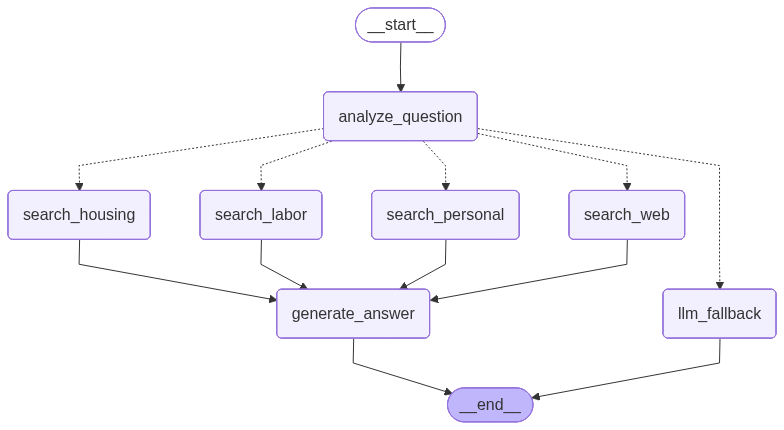

In [66]:
# 노드 정의를 딕셔너리로 관리
nodes = {
    "analyze_question": analyze_question_tool_search,
    "search_personal": personal_rag_node,
    "search_labor": labor_rag_node,
    "search_housing": housing_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback
}

# 그래프 생성
search_builder = StateGraph(ResearchAgentState)

# 노드 추가
for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

# 엣지 추가
search_builder.add_edge(START, "analyze_question")

# 조건부 엣지 (병렬 처리)
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"]
)

# 검색 노드들을 generate_answer에 연결
for node in ["search_personal", "search_labor", "search_housing", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", END)
search_builder.add_edge("llm_fallback", END)

# 그래프 컴파일
rag_search_graph = search_builder.compile()

# 그래프 시각화
display(Image(rag_search_graph.get_graph().draw_mermaid_png()))

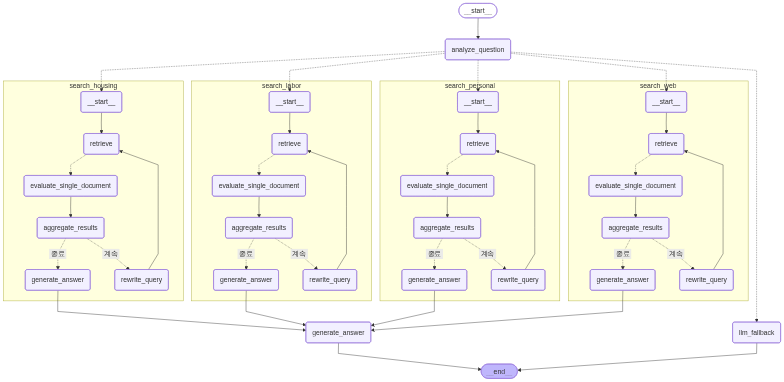

In [67]:
# 그래프 시각화
display(Image(rag_search_graph.get_graph(xray=True).draw_mermaid_png()))

In [68]:
# 1개의 도구가 선택된 경우
inputs = {
    "question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"
}
for output in rag_search_graph.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

도구 선택을 위해 질문 분석 중: 대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?
선택된 도구들: ['search_housing']
"Node 'analyze_question':"
"Value: {'datasources': ['search_housing'], 'agent_responses': {}}"

----------------------------------------------------------

--- 주택임대차보호법 전문가 에이전트 시작 ---
---주택임대차보호법 문서 검색---
---주택임대차보호법 관련 4개 문서에 대한 평가 병렬 워커 생성---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 437...)---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 243...)---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 454...)---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 264...)---
고품질 정보 1개 추출됨
문서 관련성이 낮음: 0.7
고품질 정보 4개 추출됨
고품질 정보 4개 추출됨
---주택임대차보호법 관련 총 9개의 정보 조각 집계---
EmbeddingsRedundantFilter 중복 제거: 9 → 7개
최종 결과: 9 → 7  → 7개
---주택임대차보호법 답변 생성---
"Node 'search_housing':"
("Value: {'answers': ['```markdown\\n# 대리인과 아파트 임대차 계약 체결 시 주의사항\\n\\n## 1. "
 '질문에 대한 직접적인 답변\\n대리인을 통해 아파트 임대차 계약을 체결할 때는 계약 갱신 조건과 통지 기간을 명확히 이해하고 준수해야 '
 '하며, 임대차 기간, 차임 및 보증금 등의 주요 계약 내용을 반드시 확인해야 합니다. 또한, 임대차계약은 서면으로 체결하고 표준계약서를 '
 '우선 사용하며, 임차인의 의무 이행 상태(예: 연체 여부)도 반드시 점검해야 합니다.\\n\\n## 2. 관련 법률

In [69]:
# 마크다운 형식으로 출력
from IPython.display import Markdown
display(Markdown(value['final_answer']))

1. **핵심 답변**  
대리인을 통해 아파트 임대차 계약을 체결할 때는 대리인의 권한 확인, 계약서의 서면 작성 및 표준계약서 사용, 임대차 기간과 차임·보증금 등 주요 계약 조건의 명확한 확인, 계약 갱신 조건과 갱신 거절 통지 기간 준수, 임차인의 의무 이행 상태(예: 차임 연체 여부) 점검, 그리고 확정일자 부여 및 계약서 보관에 특히 주의해야 합니다. 이러한 절차를 철저히 지켜야 임대인과 임차인 모두 권리를 보호하고 분쟁을 예방할 수 있습니다.

2. **법적 근거**  
- **대리인 권한 확인**: 대리인이 계약을 체결할 때는 위임장 등 대리권을 명확히 확인해야 합니다.  
- **서면 계약 및 표준계약서 사용**: 임대차계약은 반드시 서면으로 체결하며, 법무부장관과 국토교통부장관이 협의하여 정한 주택임대차표준계약서를 우선 사용해야 합니다. (주택임대차보호법 제30조)  
- **계약 갱신 및 통지 의무**: 임대차 기간 종료 6개월 전부터 2개월 전까지 임대인이 갱신 거절 통지를 하지 않으면 계약은 동일 조건으로 자동 갱신됩니다. 임차인도 2개월 전까지 갱신 거절 의사를 통지하지 않으면 자동 갱신됩니다. (주택임대차보호법 제6조)  
- **임대인의 정보 제공 의무**: 임대인은 임차인에게 확정일자 부여일, 차임, 보증금 등의 정보를 제공해야 하며, 임차인의 동의를 받으면 납세증명서 제시 의무를 갈음할 수 있습니다. (주택임대차보호법 제3조의7)  
- **임차인의 의무 위반 시 자동 갱신 배제**: 임차인이 2기 차임액 이상 연체하거나 의무를 현저히 위반한 경우 자동 갱신 규정이 적용되지 않습니다. (주택임대차보호법 제6조)

3. **실무적 적용**  
- **대리인 권한 확인**: 계약 체결 전에 대리인의 위임장 등 권한 증빙 서류를 반드시 확인하여 대리권 범위를 명확히 해야 합니다.  
- **계약서 작성 및 보관**: 계약은 반드시 서면으로 작성하고, 주택임대차표준계약서를 우선 사용하며, 계약서 사본을 임대인과 임차인 모두가 보관해야 합니다.  
- **확정일자 부여**: 임차인의 권리 보호를 위해 계약서에 확정일자를 부여받아야 하며, 이는 임대차보호법상 우선변제권 확보에 중요합니다.  
- **갱신 거절 통지 시기 준수**: 예를 들어 임대차 기간이 12월 31일 종료라면, 임대인은 6월 30일부터 10월 31일 사이에 갱신 거절 통지를 해야 하며, 이를 놓치면 자동 갱신됩니다.  
- **임차인의 의무 이행 상태 점검**: 임차인이 차임을 2기 이상 연체하거나 계약 의무를 현저히 위반한 경우 자동 갱신이 배제되므로, 대리인 계약 시 임차인의 의무 이행 상태를 반드시 확인해야 합니다.

4. **주의사항**  
- 대리인이 계약을 체결할 때는 반드시 대리권 범위를 명확히 하고, 임대인과 임차인 모두가 이를 인지해야 합니다.  
- 계약 갱신 거절 통지 기간을 엄수하지 않으면 자동 갱신되어 원하지 않는 계약 연장이 발생할 수 있으므로 주의해야 합니다.  
- 임차인의 의무 위반 여부를 확인하지 않으면 자동 갱신이 되지 않는 상황에서 분쟁이 발생할 수 있으므로, 임차인의 차임 납부 상태 등을 꼼꼼히 점검해야 합니다.

---

**요약**: 대리인과 아파트 임대차 계약을 체결할 때는 대리인의 권한 확인, 서면 계약 및 표준계약서 사용, 계약 조건과 갱신·통지 의무의 명확한 이해, 임차인의 의무 이행 상태 점검, 확정일자 부여 및 계약서 보관을 철저히 해야 하며, 이를 통해 권리 보호와 분쟁 예방이 가능합니다.  
(출처: 주택임대차보호법 제3조의7, 제6조, 제30조 종합)

In [70]:
# 2개의 도구가 선택된 경우
inputs = {"question": "근로계약 체결할 때 개인정보 취급 상의 유의사항은 무엇인가요?"}
for output in rag_search_graph.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

도구 선택을 위해 질문 분석 중: 근로계약 체결할 때 개인정보 취급 상의 유의사항은 무엇인가요?
선택된 도구들: ['search_labor', 'search_personal']
"Node 'analyze_question':"
("Value: {'datasources': ['search_labor', 'search_personal'], "
 "'agent_responses': {}}")

----------------------------------------------------------

--- 근로기준법 전문가 에이전트 시작 ---
---근로기준법 문서 검색---
--- 개인정보보호법 전문가 에이전트 시작 ---
---개인정보보호법 문서 검색---
---근로기준법 관련 4개 문서에 대한 평가 병렬 워커 생성---
---근로기준법 단일 문서 처리 중 (길이: 365...)---
---근로기준법 단일 문서 처리 중 (길이: 331...)---
---근로기준법 단일 문서 처리 중 (길이: 146...)---
---근로기준법 단일 문서 처리 중 (길이: 205...)---
---개인정보보호법 관련 4개 문서에 대한 평가 병렬 워커 생성---
---개인정보보호법 단일 문서 처리 중 (길이: 1001...)---
---개인정보보호법 단일 문서 처리 중 (길이: 1094...)---
---개인정보보호법 단일 문서 처리 중 (길이: 452...)---
---개인정보보호법 단일 문서 처리 중 (길이: 490...)---
문서 관련성이 낮음: 0.3
문서 관련성이 낮음: 0.5
고품질 정보 2개 추출됨
고품질 정보 3개 추출됨
문서 관련성이 낮음: 0.5
---근로기준법 관련 총 2개의 정보 조각 집계---
문서 관련성이 낮음: 0.4
EmbeddingsRedundantFilter 중복 제거: 2 → 2개
최종 결과: 2 → 2  → 2개
---근로기준법 답변 생성---
고품질 정보 3개 추출됨
고품질 정보 4개 추출됨
---개인정보보호법 관련 총 10개의 정보 조각 집계

In [71]:
# 마크다운 형식으로 출력
from IPython.display import Markdown
display(Markdown(value['final_answer']))

1. **핵심 답변**  
근로계약 체결 시 개인정보 취급에 있어 가장 중요한 유의사항은 근로자의 명확한 동의를 받고, 계약 체결 및 이행에 필요한 최소한의 개인정보만 수집·이용하는 것입니다. 개인정보 수집 목적, 항목, 보유 및 이용 기간, 동의 거부 권리 및 그에 따른 불이익 여부를 근로자에게 명확히 고지해야 하며, 개인정보는 안전하게 관리하고 계약 종료 후 불필요한 정보는 지체 없이 파기해야 합니다. 특히 18세 미만 근로자와 계약할 경우에는 근로조건을 서면 또는 전자문서로 명확히 명시하고, 부모 또는 법정대리인의 동의를 받는 등 추가 보호 조치를 취해야 합니다.

2. **법적 근거**  
- **근로기준법 제67조 ③**: 18세 미만 근로자와 근로계약 체결 시 근로조건을 서면 또는 전자문서로 명시하여 교부해야 함.  
- **개인정보 보호법 제15조(개인정보의 수집·이용)**: 개인정보 수집 시 정보주체의 동의를 받고, 수집 목적·항목·보유 기간·동의 거부 권리 등을 명확히 고지해야 함.  
- **개인정보 보호법 제16조(개인정보의 수집 제한)**: 계약 목적에 필요한 최소한의 개인정보만 수집해야 하며, 초과 수집에 대해 동의하지 않을 권리가 있음을 알려야 함.  
- **개인정보 보호법 제30조(개인정보의 안전한 관리)**: 개인정보 처리방침 수립·공개, 안전성 확보 조치, 개인정보 보호책임자 지정 등을 의무화함.  
(출처: 근로기준법 제67조 ③, 개인정보 보호법 제15조·16조·30조)

3. **실무적 적용**  
- **동의 절차**: 근로계약서 내에 개인정보 수집 및 이용에 관한 동의 조항을 포함하거나 별도의 동의서를 받아야 하며, 동의 내용은 구체적이고 명확해야 합니다.  
- **최소한의 정보 수집**: 이름, 주민등록번호, 연락처 등 계약 이행에 필수적인 정보만 수집하고, 민감정보(건강정보 등)는 별도의 동의 없이는 수집하지 않습니다.  
- **개인정보 처리방침 공개**: 회사 홈페이지나 근로자에게 쉽게 접근 가능한 방법으로 처리방침을 공개하여 근로자가 언제든지 확인할 수 있도록 합니다.  
- **안전성 확보**: 개인정보는 암호화, 접근 권한 제한, 보안 시스템 도입 등 기술적·관리적 조치를 통해 안전하게 관리하며, 계약 종료 후 불필요한 개인정보는 즉시 파기합니다.  
- **미성년자 보호**: 18세 미만 근로자의 경우 부모 또는 법정대리인의 동의를 받는 것이 바람직하며, 개인정보 보호에 더욱 신경 써야 합니다.

4. **최신 동향**  
최근 개인정보 보호법 강화 추세에 따라 기업들은 개인정보 처리방침을 더욱 엄격히 관리하고 있으며, 개인정보 유출 사고에 대한 법적 책임과 처벌이 강화되고 있습니다. 이에 따라 근로계약 시 개인정보 취급 절차를 체계적으로 마련하고, 근로자에게 충분한 정보를 제공하는 것이 중요해지고 있습니다.

5. **주의사항**  
- 개인정보 수집에 대한 동의는 자유롭게 거부할 수 있으며, 동의 거부를 이유로 근로계약 체결이나 근로조건에 불이익을 주어서는 안 됩니다.  
- 민감정보(예: 건강정보, 인종, 사상 등)는 별도의 엄격한 동의 절차가 필요하며, 불필요한 수집을 피해야 합니다.  
- 미성년자 근로자의 개인정보는 법정대리인의 동의가 필수이며, 개인정보 보호에 각별히 주의해야 합니다.

---

**요약**  
근로계약 체결 시 개인정보는 근로자의 동의를 받고, 계약 이행에 필요한 최소한의 범위 내에서만 수집·이용해야 하며, 개인정보 처리방침을 수립·공개하고 안전하게 관리해야 합니다. 18세 미만 근로자와 계약할 때는 근로조건을 서면 또는 전자문서로 명확히 명시하고, 추가적인 보호 조치를 취해야 합니다. 이를 통해 개인정보 침해 위험을 최소화하고 근로자와의 신뢰를 구축할 수 있습니다.

---

**참고 문헌**  
- 근로기준법 제67조 ③  
- 개인정보 보호법 제15조, 제16조, 제30조 (출처: 대한민국 개인정보 보호법)

# 5. 답변 평가 및 확인

### 5-1. 답변을 평가하는 ReAct 에이전트

In [72]:
from textwrap import dedent

evaluation_prompt = dedent("""
당신은 AI 어시스턴트가 생성한 답변을 평가하는 전문가입니다. 주어진 질문과 답변을 평가하고, 60점 만점으로 점수를 매기세요. 다음 기준을 사용하여 평가하십시오:

1. 정확성 (10점)
2. 관련성 (10점)
3. 완전성 (10점)
4. 인용 정확성 (10점)
5. 명확성과 간결성 (10점)
6. 객관성 (10점)

평가 과정:
1. 주어진 질문과 답변을 주의 깊게 읽으십시오.
2. 필요한 경우, 다음 도구를 사용하여 추가 정보를 수집하세요:
   - web_search: 웹 검색
   - personal_law_search: 개인정보보호법 검색
   - labor_law_search: 근로기준법 검색
   - housing_law_search: 주택임대차보호법 검색

   도구 사용 형식:
   Action: [tool_name]
   Action Input: [input for the tool]

3. 각 기준에 대해 1-10점 사이의 점수를 매기세요.
4. 총점을 계산하세요 (60점 만점).

출력 형식:
{
  "scores": {
    "accuracy": 0,
    "relevance": 0,
    "completeness": 0,
    "citation_accuracy": 0,
    "clarity_conciseness": 0,
    "objectivity": 0
  },
  "total_score": 0,
  "brief_evaluation": "간단한 평가 설명"
}

최종 출력에는 각 기준의 점수, 총점, 그리고 간단한 평가 설명만 포함하세요.
""")

In [73]:
tools

[StructuredTool(name='personal_law_search', description='개인정보보호법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.personal_law_search'>, func=<function personal_law_search at 0x000001B1F82699E0>),
 StructuredTool(name='labor_law_search', description='근로기준법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.labor_law_search'>, func=<function labor_law_search at 0x000001B1F82691C0>),
 StructuredTool(name='housing_law_search', description='주택임대차보호법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.housing_law_search'>, func=<function housing_law_search at 0x000001B1F826BBA0>),
 StructuredTool(name='web_search', description='데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function web_search at 0x000001B1F8268680>)]

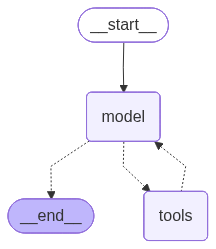

In [74]:
from langchain.agents import create_agent
from IPython.display import Image, display

# 그래프 생성 
answer_reviewer = create_agent(
    model=ChatOpenAI(model="gpt-4.1"), 
    tools=tools, 
    system_prompt=evaluation_prompt,
    )

# 그래프 출력
display(Image(answer_reviewer.get_graph().draw_mermaid_png()))

In [75]:
# 그래프 실행
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content=f"""<질문>\n{value['question']}\n</질문>\n<답변>\n{value['final_answer']}\n</답변>""")]
response = answer_reviewer.invoke({"messages": messages})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

<질문>
근로계약 체결할 때 개인정보 취급 상의 유의사항은 무엇인가요?
</질문>
<답변>
1. **핵심 답변**  
근로계약 체결 시 개인정보 취급에 있어 가장 중요한 유의사항은 근로자의 명확한 동의를 받고, 계약 체결 및 이행에 필요한 최소한의 개인정보만 수집·이용하는 것입니다. 개인정보 수집 목적, 항목, 보유 및 이용 기간, 동의 거부 권리 및 그에 따른 불이익 여부를 근로자에게 명확히 고지해야 하며, 개인정보는 안전하게 관리하고 계약 종료 후 불필요한 정보는 지체 없이 파기해야 합니다. 특히 18세 미만 근로자와 계약할 경우에는 근로조건을 서면 또는 전자문서로 명확히 명시하고, 부모 또는 법정대리인의 동의를 받는 등 추가 보호 조치를 취해야 합니다.

2. **법적 근거**  
- **근로기준법 제67조 ③**: 18세 미만 근로자와 근로계약 체결 시 근로조건을 서면 또는 전자문서로 명시하여 교부해야 함.  
- **개인정보 보호법 제15조(개인정보의 수집·이용)**: 개인정보 수집 시 정보주체의 동의를 받고, 수집 목적·항목·보유 기간·동의 거부 권리 등을 명확히 고지해야 함.  
- **개인정보 보호법 제16조(개인정보의 수집 제한)**: 계약 목적에 필요한 최소한의 개인정보만 수집해야 하며, 초과 수집에 대해 동의하지 않을 권리가 있음을 알려야 함.  
- **개인정보 보호법 제30조(개인정보의 안전한 관리)**: 개인정보 처리방침 수립·공개, 안전성 확보 조치, 개인정보 보호책임자 지정 등을 의무화함.  
(출처: 근로기준법 제67조 ③, 개인정보 보호법 제15조·16조·30조)

3. **실무적 적용**  
- **동의 절차**: 근로계약서 내에 개인정보 수집 및 이용에 관한 동의 조항을 포함하거나 별도의 동의서를 받아야 하며, 동의 내용은 구체적이고 명확해야 합니다.  
- **최소한의 정보 수집

In [76]:
pprint(json.loads(m.content))

{'brief_evaluation': '답변은 질문에 정확하게 부합하며, 법적 근거와 실무 적용 방안, 최신 동향, 주의사항 등을 포괄적으로 '
                     '안내하고 있습니다. 인용된 조항들도 실제로 관련 내용을 담고 있지만, 각 조항의 조문 내용을 직접 '
                     '확인·요약한 부분에서 약간의 간략함(요약 위주)이 관찰되어 인용 정확성에서 1점 감점했습니다. '
                     '전체적으로 매우 완성도 높은 답변입니다.',
 'scores': {'accuracy': 10,
            'citation_accuracy': 9,
            'clarity_conciseness': 10,
            'completeness': 10,
            'objectivity': 10,
            'relevance': 10},
 'total_score': 59}


### 5-2. 답변 평가 내용을 확인하는 HITL 추가

In [77]:
from langgraph.types import interrupt, Command
from langchain_core.messages import HumanMessage

# 답변 평가하는 노드를 추가
def evaluate_answer_node(state:ResearchAgentState):
    question = state["question"]
    final_answer = state["final_answer"]

    messages = [HumanMessage(content=f"""[질문]\n{question}\n[답변]\n{final_answer}""")]
    response = answer_reviewer.invoke({"messages": messages})
    response_dict = json.loads(response['messages'][-1].content)

    return {"evaluation_report": response_dict, "question": question, "final_answer": final_answer}


# interrupt를 사용한 HITL 노드
def human_review_node(state: ResearchAgentState):
    """interrupt를 사용한 사람의 검토 노드"""
    
    # 사용자에게 표시할 정보 구성
    review_data = {
        "question": state["question"],
        "final_answer": state["final_answer"],
        "evaluation_report": state["evaluation_report"],
        "total_score": state["evaluation_report"].get("total_score", 0),
        "brief_evaluation": state["evaluation_report"].get("brief_evaluation", ""),
        "instruction": "답변을 검토해주세요 (approve/reject):"
    }
    
    print(f"\n현재 답변: {state['final_answer']}")
    print(f"평가 결과: 총점 {state['evaluation_report']['total_score']}/60")
    print(f"{state['evaluation_report']['brief_evaluation']}")
    
    # interrupt를 사용하여 사용자 입력 대기
    user_input = interrupt(value=review_data)
    
    # 사용자 입력 처리 개선
    if isinstance(user_input, dict):
        decision = user_input.get("decision", "").lower()
        feedback = user_input.get("feedback", "")
    elif isinstance(user_input, str):
        if user_input.lower() in ['y', 'yes', 'approve', 'approved', 'ok']:
            decision = "approved"
            feedback = ""
        else:
            decision = "rejected"
            feedback = user_input if user_input else "답변이 거부되었습니다."
    else:
        # 빈 입력이나 None인 경우 기본값 설정
        decision = "rejected"
        feedback = "입력이 없어 자동으로 거부되었습니다."
    
    return {
        "user_decision": decision,
        "user_feedback": feedback,
        "iteration_count": state.get("iteration_count", 0) + 1
    }


# 조건부 라우팅 함수
def route_after_human_review(state: ResearchAgentState) -> Literal["approved", "rejected"]:
    """human_review 노드 후 라우팅 결정"""
    user_decision = state.get("user_decision", "").lower()
    
    if user_decision in ["approved", "approve", "y", "yes"]:
        return "approved"
    else:
        return "rejected"

# 승인된 경우 처리하는 노드
def approved_node(state: ResearchAgentState):
    """답변이 승인된 경우의 최종 처리"""
    print("✅ 답변이 승인되었습니다!")
    return {
        "user_decision": "approved",
        "final_answer": state["final_answer"]
    }

# 거부된 경우 처리하는 노드 
def rejected_node(state: ResearchAgentState):
    """답변이 거부된 경우의 처리"""
    print(f"❌ 답변이 거부되었습니다. 피드백: {state.get('user_feedback', '')}")
    
    # 최대 반복 횟수 체크 (예: 3회)
    if state.get("iteration_count", 0) >= 3:
        print("최대 반복 횟수에 도달했습니다. 현재 답변으로 진행합니다.")
        return {"final_answer": f"[최대 수정 후 자동 승인] {state['final_answer']}"}
    
    
    return {
        "user_feedback": state.get("user_feedback", ""),
        "iteration_count": state.get("iteration_count", 0)
    }


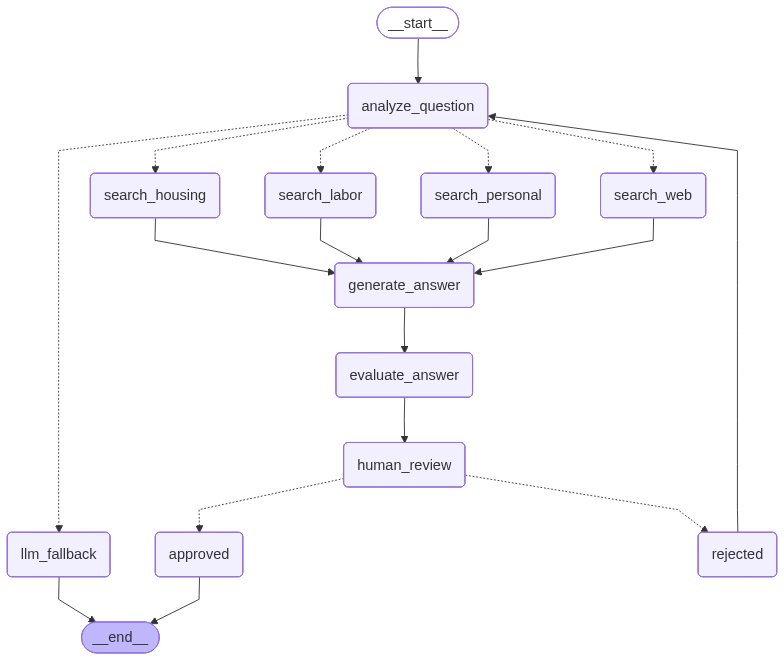

In [78]:
from langgraph.checkpoint.memory import InMemorySaver

# 노드 정의
nodes = {
    "analyze_question": analyze_question_tool_search,
    "search_personal": personal_rag_node,
    "search_labor": labor_rag_node,
    "search_housing": housing_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback,
    "evaluate_answer": evaluate_answer_node,
    "human_review": human_review_node,
    "approved": approved_node,
    "rejected": rejected_node,  # 거부 처리 노드 추가
}

# StateGraph 생성
search_builder = StateGraph(ResearchAgentState)

# 노드 추가
for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

# 엣지 추가
search_builder.add_edge(START, "analyze_question")

# 조건부 엣지 - 데이터 소스 라우팅
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"]
)

# 검색 노드들을 generate_answer에 연결
for node in ["search_personal", "search_labor", "search_housing", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", "evaluate_answer")
search_builder.add_edge("evaluate_answer", "human_review")

# HITL 결과에 따른 조건부 엣지 - 수정된 부분
search_builder.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "approved": "approved",  # approved 노드로 이동
        "rejected": "rejected"   # rejected 노드로 이동
    }
)

# 최종 엣지들
search_builder.add_edge("approved", END)
search_builder.add_edge("rejected", "analyze_question")  # 거부 시 처음부터 다시 시작
search_builder.add_edge("llm_fallback", END)

# 메모리 추가 (interrupt 사용을 위해 필수)
checkpointer = InMemorySaver()

# 그래프 컴파일
legal_rag_agent = search_builder.compile(checkpointer=checkpointer)

# 그래프 시각화
display(Image(legal_rag_agent.get_graph().draw_mermaid_png()))

In [79]:
# 질문 입력
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}

# 스레드 설정
thread_config = {
    "configurable": {
        "thread_id": "legal_rag_thread",
    }
}
for output in legal_rag_agent.stream(inputs, config=thread_config):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

도구 선택을 위해 질문 분석 중: 대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?
선택된 도구들: ['search_housing']
"Node 'analyze_question':"
"Value: {'datasources': ['search_housing'], 'agent_responses': {}}"

----------------------------------------------------------

--- 주택임대차보호법 전문가 에이전트 시작 ---
---주택임대차보호법 문서 검색---
---주택임대차보호법 관련 4개 문서에 대한 평가 병렬 워커 생성---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 437...)---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 243...)---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 454...)---
---주택임대차보호법 관련 단일 문서 처리 중 (길이: 264...)---
문서 관련성이 낮음: 0.75
문서 관련성이 낮음: 0.75
고품질 정보 3개 추출됨
고품질 정보 4개 추출됨
---주택임대차보호법 관련 총 7개의 정보 조각 집계---
EmbeddingsRedundantFilter 중복 제거: 7 → 6개
최종 결과: 7 → 6  → 6개
---주택임대차보호법 답변 생성---
"Node 'search_housing':"
("Value: {'answers': ['```markdown\\n# 대리인과 아파트 임대차 계약 체결 시 주의사항\\n\\n## 1. "
 '질문에 대한 직접적인 답변\\n대리인을 통해 아파트 임대차 계약을 체결할 때는 다음 사항에 주의해야 합니다.\\n\\n- 임대인은 '
 '임차인(대리인 포함)에게 확정일자 부여일, 차임 및 보증금 등의 중요한 정보를 반드시 제시해야 합니다.\\n- 임대차 계약 갱신 조건과 '
 '통지 기간을 명확히 이해하고 준수해야 하며, 임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또

In [80]:
# 현재 중단된 노드 확인
key

'__interrupt__'

In [81]:
# 중단점의 상태 값 확인
pprint(value[0].value)

{'brief_evaluation': '답변은 법적 근거와 실무적 주의사항을 구체적으로 명시하였고, 관련 법 조항의 인용도 정확합니다. '
                     '내용이 다소 길지만 핵심 내용은 잘 정리되어 있으며, 객관적이고 명확합니다. 명확성과 간결성에서 '
                     '약간의 간추림이 더 있었으면 좋겠습니다.',
 'evaluation_report': {'brief_evaluation': '답변은 법적 근거와 실무적 주의사항을 구체적으로 명시하였고, '
                                           '관련 법 조항의 인용도 정확합니다. 내용이 다소 길지만 핵심 '
                                           '내용은 잘 정리되어 있으며, 객관적이고 명확합니다. 명확성과 '
                                           '간결성에서 약간의 간추림이 더 있었으면 좋겠습니다.',
                       'scores': {'accuracy': 10,
                                  'citation_accuracy': 10,
                                  'clarity_conciseness': 9,
                                  'completeness': 10,
                                  'objectivity': 10,
                                  'relevance': 10},
                       'total_score': 59},
 'final_answer': '1. **핵심 답변**  \n'
                 '대리인을 통해 아파트 임대차 계약을 체결할 때는 대리인의 권한 범위와 신분을 명확히 확인하고, 임대인이

- **사용자 개입 (HITL): 거부**

    - 사용자가 승인을 해주지 않는 경우, 피드백을 통해 다시 생성
    - **Command** 함수로 사용자 피드백 전달

In [82]:
from langgraph.types import Command

# 사용자 피드백 제공 (거부)
human_feedback = {
    "decision": "rejected",
    "feedback": "답변에 대한 출처가 충분히 구체적이지 않습니다. 인용된 법조항에 대한 구체적 조문과 더 많은 세부사항이 필요합니다."
}

# 사용자 입력으로 그래프 재개
for output in legal_rag_agent.stream(Command(resume=human_feedback), config=thread_config):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")


현재 답변: 1. **핵심 답변**  
대리인을 통해 아파트 임대차 계약을 체결할 때는 대리인의 권한 범위와 신분을 명확히 확인하고, 임대인이 임차인(대리인 포함)에게 확정일자 부여일, 차임, 보증금 등 중요한 계약 조건을 반드시 명확히 제시해야 합니다. 또한, 임대차 계약 갱신과 관련한 통지 의무(임대인은 계약 종료 6개월 전부터 2개월 전까지, 임차인은 2개월 전까지 갱신 거절 의사 통지)를 철저히 준수해야 하며, 이를 놓치면 자동 갱신될 수 있으므로 주의가 필요합니다.

2. **법적 근거**  
- **주택임대차보호법 제3조의7**: 임대인은 임대차계약 체결 시 임차인에게 확정일자 부여일, 차임, 보증금 등의 정보를 제공해야 하며, 납세증명서 대신 미납국세 및 미납지방세 열람으로 갈음할 수 있음  
- **주택임대차보호법 제6조(계약의 갱신)**: 임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 하며, 임차인도 2개월 전까지 갱신 거절 의사를 통지하지 않으면 기존 조건으로 자동 갱신됨  

3. **실무적 적용**  
- **대리인 권한 확인**: 계약 체결 전에 위임장 등 권한 증빙 서류를 반드시 확인하여 대리인의 권한 범위를 명확히 해야 합니다.  
- **확정일자 부여 확인**: 대리인에게도 확정일자 부여 사실을 반드시 확인시켜 임차인의 보증금 우선변제권을 확보해야 합니다.  
- **갱신 통지 관리**: 임대인과 임차인 모두 갱신 거절 통지 시기를 엄수하도록 대리인을 통해서도 철저히 관리해야 합니다.  
- **임대인의 납세증명서 제시**: 임대인이 동의하면 납세증명서 대신 미납국세 및 미납지방세 열람으로 대체 가능하므로, 계약 시 이 부분도 확인할 수 있습니다.

4. **주의사항**  
- 대리인의 권한이 불분명하거나 위임 범위를 벗어난 계약 체결 시 분쟁이 발생할 수 있으므로, 권한 범위와 신분 확인에 특히 신경 써야 합니다.  
- 계약 갱신 관련 통지 의무를 놓치면 자동 갱신되어 원하지

In [83]:
# 현재 상태 - 그래프 체크포인트 확인
current_state = legal_rag_agent.get_state(thread_config)

print(f"\n현재 상태: {current_state.values}")
print(f"대기 중인 interrupt: {current_state.tasks}")


현재 상태: {'question': '대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?', 'answers': ['```markdown\n# 대리인과 아파트 임대차 계약 체결 시 주의사항\n\n## 1. 질문에 대한 직접적인 답변\n대리인을 통해 아파트 임대차 계약을 체결할 때는 다음 사항에 주의해야 합니다.\n\n- 임대인은 임차인(대리인 포함)에게 확정일자 부여일, 차임 및 보증금 등의 중요한 정보를 반드시 제시해야 합니다.\n- 임대차 계약 갱신 조건과 통지 기간을 명확히 이해하고 준수해야 하며, 임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 합니다.\n- 임차인(대리인 포함)이 갱신 거절 의사를 계약 종료 2개월 전까지 통지하지 않으면 기존 조건으로 자동 갱신됩니다.\n- 임대차 계약 체결 시 임대인의 납세증명서 제시 의무가 있는데, 임대인이 동의하면 미납국세 및 미납지방세 열람으로 갈음할 수 있습니다.\n- 대리인이 계약을 체결하는 경우에도 임차인의 권리와 의무가 동일하게 적용되므로, 대리인의 권한 위임 범위와 신분 확인이 중요합니다.\n\n## 2. 관련 법률 조항 및 해석\n- **주택임대차보호법 제3조의7**  \n  임대인은 임대차계약 체결 시 임차인에게 확정일자 부여일, 차임 및 보증금 등의 정보를 제시해야 하며, 임대인이 동의하면 납세증명서 대신 미납국세 및 미납지방세 열람으로 갈음할 수 있습니다.  \n  (출처: 주택임대차보호법 제3조의7)\n\n- **주택임대차보호법 제6조(계약의 갱신)**  \n  임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 하며, 이를 하지 않으면 기존 조건으로 자동 갱신됩니다. 임차인도 2개월 전까지 갱신 거절 의사를 통지하지 않으면 자동 갱신됩니다.  \n  (출처: 주택임대차보호법 제6조)\n\n## 3. 추가 설명 또는 예시\n- **대리인 권한 확인**  \n  대리인이 계약을 

In [84]:
# 대기 중인 interrupt 확인
task = current_state.tasks[0]
print(task.id)
print(task.name)
pprint(task.interrupts[0].value)

228ef608-6f41-b5ce-5879-4b8fccf13320
human_review
{'brief_evaluation': '답변은 대리인을 통한 아파트 임대차 계약 시 주의점, 법적 근거, 실무적 적용, 요약 등 다양한 '
                     '측면을 구체적이고 명확하게 제시했습니다. 주된 법 조항도 정확히 인용했으나, 대리인의 권한 '
                     '증명(위임장 등)과 본인확인 관련 실제 서류나 구체적인 절차 언급이 보완됐다면 더 완벽했을 것입니다. '
                     '전반적으로 객관적이고 일관성 있으며 정보도 명확하고 완전합니다.',
 'evaluation_report': {'brief_evaluation': '답변은 대리인을 통한 아파트 임대차 계약 시 주의점, 법적 '
                                           '근거, 실무적 적용, 요약 등 다양한 측면을 구체적이고 '
                                           '명확하게 제시했습니다. 주된 법 조항도 정확히 인용했으나, '
                                           '대리인의 권한 증명(위임장 등)과 본인확인 관련 실제 서류나 '
                                           '구체적인 절차 언급이 보완됐다면 더 완벽했을 것입니다. '
                                           '전반적으로 객관적이고 일관성 있으며 정보도 명확하고 '
                                           '완전합니다.',
                       'scores': {'accuracy': 9,
                                  'citation_accuracy': 9,
                             

In [85]:
# 다음에 실행될 노드를 확인 
current_state.next

('human_review',)

- **사용자 개입 (HITL): 승인**

- 사용자가 '승인'을 해서 최종 답변을 생성하고 종료

In [86]:
from langgraph.types import Command

# 사용자 피드백 제공 (승인 문자열을 사용)
human_feedback = "approved"

# 사용자 입력으로 그래프 재개
for output in legal_rag_agent.stream(Command(resume=human_feedback), config=thread_config):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")


현재 답변: 1. **핵심 답변**  
대리인과 아파트 임대차 계약을 체결할 때는 임대인의 정보 제공 의무(확정일자, 차임, 보증금, 납세증명서 등)를 반드시 확인하고, 대리인의 계약 체결 권한과 임대인의 사전 동의 여부를 명확히 해야 합니다. 또한, 계약 갱신 거절 통지 시기(임대차 종료 6개월 전부터 2개월 전까지)를 엄수하고, 임차인의 의무 위반 여부(차임 연체 등)를 점검하여 계약 갱신 제한 가능성을 고려해야 합니다. 계약서 작성 시에는 주택임대차표준계약서를 우선 사용하되, 당사자 간 합의가 있으면 다른 서식도 가능합니다.

2. **법적 근거**  
- **주택임대차보호법 제3조의7(임대인의 정보 제공 의무)**  
  임대인은 임대차 계약 체결 시 임차인(대리인 포함)에게 확정일자 부여일, 차임, 보증금, 국세 및 지방세 납세증명서 등을 반드시 제시해야 하며, 임대인이 사전에 동의한 경우에만 이를 대체할 수 있습니다.  
- **주택임대차보호법 제6조 제1항~제3항(계약 갱신 및 갱신 거절 통지)**  
  임대차 기간 종료 6개월 전부터 2개월 전까지 임대인이 갱신 거절 통지를 하지 않으면 계약은 동일 조건으로 2년간 자동 연장됩니다. 다만, 임차인이 2기 이상의 차임을 연체하거나 계약상 의무를 현저히 위반한 경우에는 갱신 제한이 가능합니다.  
- **주택임대차보호법 제30조(표준계약서 사용)**  
  주택임대차계약은 법무부장관과 국토교통부장관이 협의하여 정한 표준계약서를 우선적으로 사용해야 하며, 당사자 간 합의가 있으면 다른 서식을 사용할 수 있습니다.

3. **실무적 적용**  
- **대리인 권한 및 임대인 동의 확인**  
  대리인이 계약을 체결할 때는 임대인의 동의서나 위임장 등 대리권을 증명하는 서류를 반드시 확보해야 하며, 임대인이 사전에 동의한 경우에만 일부 서류 제출을 대체할 수 있습니다.  
- **갱신 거절 통지 시기 엄수**  
  예를 들어, 임대차 기간이 2024년 12월 31일 종료라면, 임대인은 2024년 6

In [87]:
# 현재 상태 - 그래프 체크포인트 확인
current_state = legal_rag_agent.get_state(thread_config)

print(f"\n현재 상태: {current_state.values}")
print(f"대기 중인 interrupt: {current_state.tasks}")


현재 상태: {'question': '대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?', 'answers': ['```markdown\n# 대리인과 아파트 임대차 계약 체결 시 주의사항\n\n## 1. 질문에 대한 직접적인 답변\n대리인을 통해 아파트 임대차 계약을 체결할 때는 다음 사항에 주의해야 합니다.\n\n- 임대인은 임차인(대리인 포함)에게 확정일자 부여일, 차임 및 보증금 등의 중요한 정보를 반드시 제시해야 합니다.\n- 임대차 계약 갱신 조건과 통지 기간을 명확히 이해하고 준수해야 하며, 임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 합니다.\n- 임차인(대리인 포함)이 갱신 거절 의사를 계약 종료 2개월 전까지 통지하지 않으면 기존 조건으로 자동 갱신됩니다.\n- 임대차 계약 체결 시 임대인의 납세증명서 제시 의무가 있는데, 임대인이 동의하면 미납국세 및 미납지방세 열람으로 갈음할 수 있습니다.\n- 대리인이 계약을 체결하는 경우에도 임차인의 권리와 의무가 동일하게 적용되므로, 대리인의 권한 위임 범위와 신분 확인이 중요합니다.\n\n## 2. 관련 법률 조항 및 해석\n- **주택임대차보호법 제3조의7**  \n  임대인은 임대차계약 체결 시 임차인에게 확정일자 부여일, 차임 및 보증금 등의 정보를 제시해야 하며, 임대인이 동의하면 납세증명서 대신 미납국세 및 미납지방세 열람으로 갈음할 수 있습니다.  \n  (출처: 주택임대차보호법 제3조의7)\n\n- **주택임대차보호법 제6조(계약의 갱신)**  \n  임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 하며, 이를 하지 않으면 기존 조건으로 자동 갱신됩니다. 임차인도 2개월 전까지 갱신 거절 의사를 통지하지 않으면 자동 갱신됩니다.  \n  (출처: 주택임대차보호법 제6조)\n\n## 3. 추가 설명 또는 예시\n- **대리인 권한 확인**  \n  대리인이 계약을 

In [88]:
# 대기 중인 interrupt 확인
current_state.tasks

()

In [89]:
# 최종 상태 확인
current_state.values

{'question': '대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?',
 'answers': ['```markdown\n# 대리인과 아파트 임대차 계약 체결 시 주의사항\n\n## 1. 질문에 대한 직접적인 답변\n대리인을 통해 아파트 임대차 계약을 체결할 때는 다음 사항에 주의해야 합니다.\n\n- 임대인은 임차인(대리인 포함)에게 확정일자 부여일, 차임 및 보증금 등의 중요한 정보를 반드시 제시해야 합니다.\n- 임대차 계약 갱신 조건과 통지 기간을 명확히 이해하고 준수해야 하며, 임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 합니다.\n- 임차인(대리인 포함)이 갱신 거절 의사를 계약 종료 2개월 전까지 통지하지 않으면 기존 조건으로 자동 갱신됩니다.\n- 임대차 계약 체결 시 임대인의 납세증명서 제시 의무가 있는데, 임대인이 동의하면 미납국세 및 미납지방세 열람으로 갈음할 수 있습니다.\n- 대리인이 계약을 체결하는 경우에도 임차인의 권리와 의무가 동일하게 적용되므로, 대리인의 권한 위임 범위와 신분 확인이 중요합니다.\n\n## 2. 관련 법률 조항 및 해석\n- **주택임대차보호법 제3조의7**  \n  임대인은 임대차계약 체결 시 임차인에게 확정일자 부여일, 차임 및 보증금 등의 정보를 제시해야 하며, 임대인이 동의하면 납세증명서 대신 미납국세 및 미납지방세 열람으로 갈음할 수 있습니다.  \n  (출처: 주택임대차보호법 제3조의7)\n\n- **주택임대차보호법 제6조(계약의 갱신)**  \n  임대인은 임대차기간 종료 6개월 전부터 2개월 전까지 갱신 거절 또는 계약 조건 변경 통지를 해야 하며, 이를 하지 않으면 기존 조건으로 자동 갱신됩니다. 임차인도 2개월 전까지 갱신 거절 의사를 통지하지 않으면 자동 갱신됩니다.  \n  (출처: 주택임대차보호법 제6조)\n\n## 3. 추가 설명 또는 예시\n- **대리인 권한 확인**  \n  대리인이 계약을 체결할 때는 

In [90]:
# 다음에 실행될 노드를 확인 
current_state.next

()

In [91]:
# 마크다운 형식으로 최종 답변 출력
from IPython.display import Markdown
final_answer = current_state.values.get("final_answer", "답변이 없습니다.")
Markdown(f"### 최종 답변\n{final_answer}")

### 최종 답변
1. **핵심 답변**  
대리인과 아파트 임대차 계약을 체결할 때는 임대인의 정보 제공 의무(확정일자, 차임, 보증금, 납세증명서 등)를 반드시 확인하고, 대리인의 계약 체결 권한과 임대인의 사전 동의 여부를 명확히 해야 합니다. 또한, 계약 갱신 거절 통지 시기(임대차 종료 6개월 전부터 2개월 전까지)를 엄수하고, 임차인의 의무 위반 여부(차임 연체 등)를 점검하여 계약 갱신 제한 가능성을 고려해야 합니다. 계약서 작성 시에는 주택임대차표준계약서를 우선 사용하되, 당사자 간 합의가 있으면 다른 서식도 가능합니다.

2. **법적 근거**  
- **주택임대차보호법 제3조의7(임대인의 정보 제공 의무)**  
  임대인은 임대차 계약 체결 시 임차인(대리인 포함)에게 확정일자 부여일, 차임, 보증금, 국세 및 지방세 납세증명서 등을 반드시 제시해야 하며, 임대인이 사전에 동의한 경우에만 이를 대체할 수 있습니다.  
- **주택임대차보호법 제6조 제1항~제3항(계약 갱신 및 갱신 거절 통지)**  
  임대차 기간 종료 6개월 전부터 2개월 전까지 임대인이 갱신 거절 통지를 하지 않으면 계약은 동일 조건으로 2년간 자동 연장됩니다. 다만, 임차인이 2기 이상의 차임을 연체하거나 계약상 의무를 현저히 위반한 경우에는 갱신 제한이 가능합니다.  
- **주택임대차보호법 제30조(표준계약서 사용)**  
  주택임대차계약은 법무부장관과 국토교통부장관이 협의하여 정한 표준계약서를 우선적으로 사용해야 하며, 당사자 간 합의가 있으면 다른 서식을 사용할 수 있습니다.

3. **실무적 적용**  
- **대리인 권한 및 임대인 동의 확인**  
  대리인이 계약을 체결할 때는 임대인의 동의서나 위임장 등 대리권을 증명하는 서류를 반드시 확보해야 하며, 임대인이 사전에 동의한 경우에만 일부 서류 제출을 대체할 수 있습니다.  
- **갱신 거절 통지 시기 엄수**  
  예를 들어, 임대차 기간이 2024년 12월 31일 종료라면, 임대인은 2024년 6월 30일부터 10월 31일 사이에 갱신 거절 통지를 해야 하며, 이를 놓치면 계약은 자동으로 2년 연장됩니다.  
- **임차인 의무 이행 점검**  
  임차인이 2기 이상의 차임을 연체하거나 계약 의무를 심각하게 위반하는 경우, 임대인은 갱신을 거절할 수 있으므로 임차인의 신용 상태와 계약 이행 여부를 사전에 확인하는 것이 중요합니다.  
- **계약서 작성**  
  표준계약서를 우선 사용하되, 당사자 간 합의가 있으면 다른 계약서 양식도 가능하므로 계약서 내용과 서식을 꼼꼼히 검토해야 합니다.

4. **주의사항**  
- 대리인 계약 시 임대인의 동의가 없으면 계약 효력이 문제될 수 있으므로, 반드시 대리권 범위와 동의 여부를 명확히 해야 합니다.  
- 임대인의 정보 제공 의무를 임차인이 직접 확인하여 불이익을 방지해야 하며, 특히 확정일자 부여 여부는 임차인의 권리 보호에 중요합니다.  
- 갱신 거절 통지 시기를 놓치면 계약이 자동 연장되므로 임대인과 임차인 모두 주의해야 합니다.

---

**요약**: 대리인과 아파트 임대차 계약 체결 시에는 임대인의 정보 제공 의무 준수, 대리인의 권한 및 임대인 동의 확인, 계약 갱신 거절 통지 시기 엄수, 임차인의 의무 이행 점검, 그리고 표준계약서 사용 여부를 꼼꼼히 확인하는 것이 중요합니다. 이를 통해 계약의 법적 안정성과 당사자 권리 보호를 확보할 수 있습니다.

(출처: 주택임대차보호법 제3조의7, 제6조 제1항~3항, 제30조)

# 6. Gradio 챗봇

In [92]:
import gradio as gr
import uuid
from typing import List, Tuple, Dict, Any, Optional
from langgraph.types import Command
import json

# 예시 질문들
example_questions = [
    "개인정보 유출 시 기업이 취해야 할 법적 조치는 무엇인가요?",
    "전월세 계약 갱신 요구권의 행사 기간과 조건은 어떻게 되나요?",
    "퇴직금 지급 기준과 계산 방법은 어떻게 되나요?",
]

# 개선된 ChatBot 클래스
class LegalRAGChatBot:
    def __init__(self, graph):
        self.graph = graph
        self.thread_id = str(uuid.uuid4())
        self.waiting_for_approval = False
        self.current_interrupt_data = None
        print(f"ChatBot 초기화 완료 - Thread ID: {self.thread_id}")
    
    def get_thread_config(self):
        """스레드 설정 반환"""
        return {"configurable": {"thread_id": self.thread_id}}
    
    def format_review_message(self, interrupt_data):
        """검토 메시지 포맷팅"""
        if not interrupt_data:
            return "❌ 검토 데이터를 가져올 수 없습니다."
        
        final_answer = interrupt_data.get("final_answer", "답변 없음")
        evaluation_report = interrupt_data.get("evaluation_report", {})
        
        total_score = evaluation_report.get("total_score", 0)
        brief_evaluation = evaluation_report.get("brief_evaluation", "평가 없음")
        
        return f"""**🔍 답변 검토가 필요합니다**

**생성된 답변:**
{final_answer}

**자동 평가 결과:**
• **총점:** {total_score}/60점
• **평가:** {brief_evaluation}

---
**다음 중 하나를 선택해주세요:**
• **'y'** 또는 **'승인'** → 답변 승인
• **'n'** 또는 **'수정'** → 답변 수정 요청
• **'n: 수정의견'** → 구체적인 수정의견과 함께 수정 요청
  
**예시:** `n: 더 구체적인 사례와 벌금 기준을 추가해주세요`"""

    def process_message(self, message: str) -> str:
        """메시지 처리 메인 로직"""
        try:
            if not self.waiting_for_approval:
                # 새로운 질문 처리
                return self._handle_new_question(message)
            else:
                # 승인/거부 처리
                return self._handle_approval_decision(message)
                
        except Exception as e:
            self.waiting_for_approval = False
            self.current_interrupt_data = None
            print(f"전체 처리 오류: {e}")
            return f"❌ **오류가 발생했습니다:** {str(e)}\n\n새로운 질문을 입력해주세요."

    def _handle_new_question(self, message: str) -> str:
        """새로운 질문 처리"""
        print(f"새 질문 처리: {message}")
        
        # 초기 상태 구성
        initial_state = {
            "question": message,
            "analysis_result": {},
            "search_results": {},
            "final_answer": "",
            "evaluation_report": {},
            "user_decision": "",
            "user_feedback": "",
            "iteration_count": 0
        }
        
        try:
            config = self.get_thread_config()
            
            # graph.stream()을 사용하여 interrupt 발생 감지
            result_chunks = []
            interrupt_detected = False
            
            for chunk in self.graph.stream(initial_state, config=config):
                print(f"스트림 청크: {chunk}")
                result_chunks.append(chunk)
                
                # interrupt 발생 여부 확인
                if '__interrupt__' in chunk:
                    print("Interrupt 감지됨!")
                    interrupt_detected = True
                    
                    # interrupt 정보 추출
                    interrupts = chunk['__interrupt__']
                    if interrupts and len(interrupts) > 0:
                        interrupt_info = interrupts[0]  # 첫 번째 interrupt 사용
                        self.current_interrupt_data = interrupt_info.value
                        
                        print(f"Interrupt 데이터: {self.current_interrupt_data}")
                        
                        self.waiting_for_approval = True
                        return self.format_review_message(self.current_interrupt_data)
                    else:
                        return "❌ interrupt 데이터가 비어있습니다."
            
            # interrupt가 발생하지 않고 정상 완료된 경우
            if not interrupt_detected:
                # 마지막 상태에서 final_answer 추출
                final_state = self.graph.get_state(config)
                final_answer = final_state.values.get('final_answer', '답변을 생성할 수 없습니다.')
                return f"✅ **답변 완료**\n\n{final_answer}"
            
        except Exception as e:
            print(f"새 질문 처리 중 오류: {e}")
            raise e

    def _handle_approval_decision(self, message: str) -> str:
        """승인/거부 결정 처리"""
        print(f"승인/거부 처리: {message}")
        
        # 사용자 입력 분석
        user_input = message.strip().lower()
        
        # 결정과 피드백 분석
        if user_input in ['y', 'yes', 'approved', 'approve', '승인', '예', 'ok', '좋아']:
            decision = "approved"
            feedback = ""
        elif user_input.startswith('n:'):
            decision = "rejected"
            feedback = message[2:].strip()  # 'n:' 이후의 텍스트를 피드백으로 사용
        else:
            decision = "rejected"
            feedback = message if message not in ['n', 'no', 'reject', '수정', '거부'] else "답변 수정이 필요합니다."
        
        print(f"사용자 결정: {decision}, 피드백: {feedback}")
        
        try:
            config = self.get_thread_config()
            
            # Command를 사용하여 interrupt 지점에서 재개
            resume_data = {
                "decision": decision,
                "feedback": feedback
            }
            
            result_chunks = []
            interrupt_detected = False
            
            # Command(resume=)를 사용하여 그래프 재개
            for chunk in self.graph.stream(Command(resume=resume_data), config=config):
                print(f"재개 스트림 청크: {chunk}")
                result_chunks.append(chunk)
                
                # 또 다른 interrupt 발생 여부 확인 (수정된 답변에 대한 재검토)
                if '__interrupt__' in chunk:
                    print("재개 중 또 다른 interrupt 감지됨!")
                    interrupt_detected = True
                    
                    interrupts = chunk['__interrupt__']
                    if interrupts and len(interrupts) > 0:
                        interrupt_info = interrupts[0]
                        self.current_interrupt_data = interrupt_info.value
                        
                        # waiting_for_approval은 이미 True 상태 유지
                        response = self.format_review_message(self.current_interrupt_data)
                        # 수정된 답변임을 표시
                        response = response.replace("🔍 답변 검토가 필요합니다", "🔄 수정된 답변 검토")
                        response = response.replace("생성된 답변:", "수정된 답변:")
                        
                        return response
                    else:
                        self.waiting_for_approval = False
                        return "❌ 수정된 답변의 interrupt 데이터가 비어있습니다."
            
            # interrupt가 발생하지 않고 완료된 경우
            if not interrupt_detected:
                self.waiting_for_approval = False
                self.current_interrupt_data = None
                
                # 최종 상태에서 답변 추출
                final_state = self.graph.get_state(config)
                final_answer = final_state.values.get('final_answer', '최종 답변을 가져올 수 없습니다.')
                
                if decision == "approved":
                    return f"✅ **답변이 승인되었습니다!**\n\n{final_answer}"
                else:
                    return f"🔄 **답변 수정 완료**\n\n{final_answer}"
                
        except Exception as e:
            print(f"승인/거부 처리 중 오류: {e}")
            self.waiting_for_approval = False
            raise e

    def chat(self, message: str, history: List[Tuple[str, str]]) -> str:
        """Gradio ChatInterface용 메인 함수"""
        print(f"\n=== 채팅 호출 ===")
        print(f"Thread ID: {self.thread_id}")
        print(f"대기 상태: {self.waiting_for_approval}")
        print(f"메시지: {message}")
        print(f"히스토리 길이: {len(history)}")
        
        try:
            response = self.process_message(message)
            print(f"응답 길이: {len(response)}")
            return response
        except Exception as e:
            print(f"채팅 처리 중 오류: {e}")
            self.waiting_for_approval = False
            self.current_interrupt_data = None
            return f"❌ **처리 중 오류가 발생했습니다:** {str(e)}\n\n새로운 질문을 입력해주세요."

    def reset_session(self):
        """새로운 세션 시작"""
        old_thread_id = self.thread_id
        self.thread_id = str(uuid.uuid4())
        self.waiting_for_approval = False
        self.current_interrupt_data = None
        print(f"세션 리셋: {old_thread_id} → {self.thread_id}")
        return "🔄 새로운 대화를 시작합니다."

    def get_current_state(self):
        """현재 그래프 상태 반환 (디버깅용)"""
        try:
            config = self.get_thread_config()
            state = self.graph.get_state(config)
            return {
                "values": state.values,
                "tasks": [task.__dict__ for task in state.tasks] if state.tasks else [],
                "waiting_for_approval": self.waiting_for_approval,
                "current_interrupt_data": self.current_interrupt_data
            }
        except Exception as e:
            return {"error": str(e)}

# Gradio 인터페이스 생성 함수
def create_gradio_interface(chatbot):
    """Gradio 인터페이스를 생성하는 함수"""
    
    with gr.Blocks(
        title="생활법률 AI 어시스턴트 (HITL)", 
        theme=gr.themes.Soft(),
        css="""
        .chat-container { max-width: 1000px; margin: 0 auto; }
        .example-btn { margin: 2px; }
        """,
        analytics_enabled=False,
    ) as demo:
        
        gr.Markdown("""
        # 🏛️ 생활법률 AI 어시스턴트
        
        **주택임대차보호법**, **근로기준법**, **개인정보보호법** 관련 질문에 답변해 드립니다.
        
        """)
        
        # 메인 채팅 인터페이스
        chatinterface = gr.ChatInterface(
            fn=chatbot.chat,
            examples=example_questions,
            title="",
            description="",
            type="messages",
            textbox=gr.Textbox(
                placeholder="법률 질문을 입력하세요 (예: 퇴직금 계산 방법은?)",
                container=False,
                scale=7
            ),
            analytics_enabled=False,
        )
        
    return demo


# ChatBot 생성
chatbot = LegalRAGChatBot(legal_rag_agent)

# Gradio 인터페이스 생성 및 실행
demo = create_gradio_interface(chatbot)
demo.launch(debug=True, share=False)

ChatBot 초기화 완료 - Thread ID: 6f453a6a-f7f3-41f6-b824-27d365fd6ed7
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.



=== 채팅 호출 ===
Thread ID: 6f453a6a-f7f3-41f6-b824-27d365fd6ed7
대기 상태: False
메시지: 개인정보 유출 시 기업이 취해야 할 법적 조치는 무엇인가요?
히스토리 길이: 0
새 질문 처리: 개인정보 유출 시 기업이 취해야 할 법적 조치는 무엇인가요?
도구 선택을 위해 질문 분석 중: 개인정보 유출 시 기업이 취해야 할 법적 조치는 무엇인가요?
선택된 도구들: ['search_personal', 'search_web']
스트림 청크: {'analyze_question': {'datasources': ['search_personal', 'search_web'], 'agent_responses': {}}}
--- 개인정보보호법 전문가 에이전트 시작 ---
--- 인터넷 검색 전문가 에이전트 시작 ---
---개인정보보호법 문서 검색---
---웹 문서 검색---
---4개 웹 문서에 대한 평가 병렬 워커 생성---
---단일 웹 문서 처리 중 (길이: 100...)---
---단일 웹 문서 처리 중 (길이: 100...)---
---단일 웹 문서 처리 중 (길이: 100...)---
---단일 웹 문서 처리 중 (길이: 100...)---
---개인정보보호법 관련 4개 문서에 대한 평가 병렬 워커 생성---
---개인정보보호법 단일 문서 처리 중 (길이: 956...)---
---개인정보보호법 단일 문서 처리 중 (길이: 734...)---
---개인정보보호법 단일 문서 처리 중 (길이: 466...)---
---개인정보보호법 단일 문서 처리 중 (길이: 236...)---
고품질 웹 정보 2개 추출됨
고품질 정보 2개 추출됨
고품질 웹 정보 1개 추출됨
고품질 정보 3개 추출됨
고품질 웹 정보 3개 추출됨
고품질 정보 3개 추출됨
고품질 정보 4개 추출됨
---개인정보보호법 관련 총 12개의 정보 조각 집계---
---개인정보보호법 답변 생성---
고품질 웹 정보 3개 추출됨
---총 9개의 웹 정보 조각 집계-

---

## [실습] **법률 문서 기반 검색 에이전트 시스템 구현**

- 이전 코드를 참조하여, 에이전트 시스템을 구현합니다. 
- 도구 추가, 프롬프트 개선, 평가 로직 개선, 답변 포맷팅 등 개선 아이디어를 직접 적용합니다. 


In [93]:
"""
=====================================================================
[실습과제] 개선된 법률 문서 기반 검색 에이전트 시스템
=====================================================================

주요 개선사항:
1. 도구 추가: 법률 용어 사전, 유사 사례 검색
2. 프롬프트 개선: 구조화된 답변 생성
3. 평가 로직 개선: 더 세밀한 평가 기준과 가중치
4. 답변 포맷팅: 읽기 쉬운 마크다운 구조

=====================================================================
"""

from typing import List, Dict, Optional, Literal, Annotated
from textwrap import dedent
import json

# =====================================================================
# 1. 개선된 도구 추가
# =====================================================================

# 1-1. 법률 용어 사전 도구
def search_legal_terms(query: str) -> dict:
    """
    법률 용어를 검색하는 도구
    
    Args:
        query: 검색할 법률 용어
        
    Returns:
        용어 정의와 관련 정보
    """
    # 실제로는 법률 용어 사전 API나 DB를 연결
    # 여기서는 예시 데이터 사용
    legal_terms_db = {
        "퇴직금": {
            "definition": "근로자가 퇴직할 때 사용자가 지급하는 금품",
            "related_law": "근로기준법 제34조",
            "calculation": "계속근로기간 1년에 대하여 30일분 이상의 평균임금",
            "requirements": "계속근로기간 1년 이상"
        },
        "개인정보": {
            "definition": "살아 있는 개인에 관한 정보로서 성명, 주민등록번호 등에 의하여 특정 개인을 알아볼 수 있는 정보",
            "related_law": "개인정보보호법 제2조",
            "examples": ["성명", "주민등록번호", "영상", "생체정보", "이메일", "전화번호"],
            "special_notes": "다른 정보와 쉽게 결합하여 알아볼 수 있는 것을 포함"
        },
        "전세보증금": {
            "definition": "주택임대차계약 시 임차인이 임대인에게 지급하는 보증금",
            "related_law": "주택임대차보호법 제3조",
            "protection": "대항력, 우선변제권",
            "requirements": "주택의 인도와 전입신고"
        },
        "평균임금": {
            "definition": "산정사유 발생일 이전 3개월간 지급된 임금 총액을 그 기간의 총일수로 나눈 금액",
            "related_law": "근로기준법 제2조",
            "calculation_method": "임금총액 ÷ 3개월 총일수",
            "usage": "퇴직금, 휴업수당, 산재보상 등의 기준"
        }
    }
    
    # 검색어와 부분 일치하는 용어 찾기
    results = []
    query_lower = query.lower()
    
    for term, info in legal_terms_db.items():
        if query_lower in term.lower() or term.lower() in query_lower:
            results.append({
                "term": term,
                **info
            })
    
    if not results:
        return {
            "found": False,
            "message": f"'{query}'에 대한 법률 용어 정보를 찾을 수 없습니다."
        }
    
    return {
        "found": True,
        "query": query,
        "results": results
    }


# 1-2. 유사 사례 검색 도구
def search_similar_cases(query: str, law_type: str) -> dict:
    """
    유사한 법률 사례를 검색하는 도구
    
    Args:
        query: 검색 질의
        law_type: 법률 종류 (personal/labor/housing)
        
    Returns:
        유사 사례 정보
    """
    # 실제로는 판례 DB나 사례 DB를 연결
    # 여기서는 예시 데이터 사용
    cases_db = {
        "labor": [
            {
                "case_id": "2023가단1234",
                "title": "퇴직금 미지급 관련 판례",
                "summary": "1년 이상 계속 근무한 근로자에게 퇴직금을 지급하지 않은 경우, 근로기준법 위반으로 판단",
                "related_articles": ["근로기준법 제34조"],
                "key_points": [
                    "계속근로기간 1년 이상 시 퇴직금 지급 의무",
                    "평균임금의 30일분 이상",
                    "미지급 시 형사처벌 가능"
                ]
            },
            {
                "case_id": "2022나5678",
                "title": "부당해고 구제 사례",
                "summary": "정당한 사유 없이 근로자를 해고한 경우 부당해고로 인정",
                "related_articles": ["근로기준법 제23조"],
                "key_points": [
                    "해고는 정당한 이유가 있어야 함",
                    "해고 예고 30일 전 통지 필요",
                    "부당해고 시 복직 및 임금 지급 명령"
                ]
            }
        ],
        "housing": [
            {
                "case_id": "2023다9876",
                "title": "전세보증금 반환 관련 판례",
                "summary": "임대차계약 종료 후 임차인의 보증금 반환청구권 인정",
                "related_articles": ["주택임대차보호법 제3조"],
                "key_points": [
                    "주택 인도 및 전입신고로 대항력 취득",
                    "확정일자로 우선변제권 취득",
                    "보증금 전액 반환 원칙"
                ]
            }
        ],
        "personal": [
            {
                "case_id": "2023헌1111",
                "title": "개인정보 유출 관련 판례",
                "summary": "동의 없는 개인정보 수집 및 제3자 제공은 위법",
                "related_articles": ["개인정보보호법 제15조, 제17조"],
                "key_points": [
                    "개인정보 수집 시 동의 필수",
                    "제3자 제공 시 별도 동의 필요",
                    "위반 시 과징금 및 형사처벌"
                ]
            }
        ]
    }
    
    cases = cases_db.get(law_type, [])
    
    if not cases:
        return {
            "found": False,
            "message": f"'{law_type}' 분야의 사례를 찾을 수 없습니다."
        }
    
    # 간단한 키워드 매칭 (실제로는 semantic search 사용)
    relevant_cases = []
    query_lower = query.lower()
    
    for case in cases:
        if any(keyword in query_lower for keyword in ["퇴직금", "해고", "보증금", "개인정보", "임금"]):
            # 관련 키워드 체크
            case_text = (case["title"] + case["summary"]).lower()
            if any(keyword in case_text for keyword in query_lower.split()):
                relevant_cases.append(case)
    
    if not relevant_cases:
        relevant_cases = cases[:2]  # 키워드 매칭 실패 시 상위 2개 반환
    
    return {
        "found": True,
        "law_type": law_type,
        "cases": relevant_cases[:3]  # 최대 3개 사례 반환
    }


# =====================================================================
# 2. 개선된 프롬프트
# =====================================================================

IMPROVED_ANSWER_GENERATION_PROMPT = dedent("""
당신은 법률 전문 AI 어시스턴트입니다. 사용자의 법률 질문에 대해 정확하고 실용적인 답변을 제공해야 합니다.

## 답변 구조 (반드시 아래 형식을 따르세요)

### 📌 요약
- 질문에 대한 핵심 답변을 1-2문장으로 요약

### 📋 관련 법률 조항
- 관련 법률명과 조항 번호 명시
- 각 조항의 핵심 내용 설명

### 📖 상세 설명
- 법률 조항이 실제로 어떻게 적용되는지 설명
- 요건, 절차, 예외사항 등을 명확히 설명

### 💡 실무 적용 예시
- 구체적인 상황에서 어떻게 적용되는지 예시 제시
- 주의사항이나 추가 고려사항 안내

### ⚠️ 주의사항
- 법률 적용 시 주의해야 할 점
- 예외 상황이나 특수한 경우

### 🔗 참고사항
- 관련 조항 번호 명시
- 추가로 참고할 내용이 있다면 안내

## 답변 작성 원칙
1. **정확성**: 법률 조항을 정확히 인용하고 해석
2. **명확성**: 전문용어는 쉽게 풀어서 설명
3. **실용성**: 실제 상황에 어떻게 적용되는지 설명
4. **완전성**: 질문의 모든 측면을 다루되, 간결하게 작성
5. **객관성**: 법률적 사실을 중립적으로 전달

## 제공된 정보

**사용자 질문:**
{question}

**검색된 법률 정보:**
{legal_context}

**법률 용어 정보:**
{legal_terms}

**유사 사례:**
{similar_cases}

**사용자 피드백 (수정 시):**
{user_feedback}

위 정보를 바탕으로 위 구조에 따라 답변을 작성하세요.
""")


# =====================================================================
# 3. 개선된 평가 시스템
# =====================================================================

IMPROVED_EVALUATION_PROMPT = dedent("""
당신은 법률 답변을 평가하는 전문가입니다. 다음 기준에 따라 답변을 평가하세요.

## 평가 기준 (총 100점)

### 1. 법률적 정확성 (30점)
- 법률 조항 인용의 정확성 (10점)
- 법률 해석의 정확성 (10점)
- 법률 적용의 적절성 (10점)

### 2. 명확성 (25점)
- 구조화된 답변 형식 준수 (10점)
- 전문용어 설명의 명확성 (8점)
- 논리적 흐름과 일관성 (7점)

### 3. 완전성 (25점)
- 질문의 모든 측면 다룸 (10점)
- 관련 조항 포괄성 (8점)
- 주의사항 및 예외사항 포함 (7점)

### 4. 실용성 (20점)
- 실무 적용 예시 제공 (10점)
- 구체적인 절차나 방법 안내 (10점)

## 평가 결과 형식

다음 JSON 형식으로 평가 결과를 제공하세요:

{{
  "scores": {{
    "legal_accuracy": {{
      "article_citation": 0-10,
      "legal_interpretation": 0-10,
      "legal_application": 0-10,
      "subtotal": 0-30,
      "feedback": "상세 피드백"
    }},
    "clarity": {{
      "structure": 0-10,
      "terminology": 0-8,
      "logic_flow": 0-7,
      "subtotal": 0-25,
      "feedback": "상세 피드백"
    }},
    "completeness": {{
      "coverage": 0-10,
      "related_articles": 0-8,
      "exceptions": 0-7,
      "subtotal": 0-25,
      "feedback": "상세 피드백"
    }},
    "practicality": {{
      "examples": 0-10,
      "procedures": 0-10,
      "subtotal": 0-20,
      "feedback": "상세 피드백"
    }}
  }},
  "total_score": 0-100,
  "grade": "A+/A/B+/B/C+/C/D/F",
  "strengths": ["강점1", "강점2", "강점3"],
  "weaknesses": ["약점1", "약점2"],
  "improvement_suggestions": ["개선사항1", "개선사항2", "개선사항3"],
  "pass": true/false,
  "brief_evaluation": "전체 평가 요약 (2-3문장)"
}}

**통과 기준**: 총점 70점 이상

## 평가 대상

**질문:**
{question}

**답변:**
{answer}

위 답변을 평가하고 JSON 형식으로 결과를 제공하세요.
""")


def improved_evaluate_answer(question: str, answer: str, llm) -> dict:
    """
    개선된 답변 평가 함수
    
    Args:
        question: 원본 질문
        answer: 생성된 답변
        llm: 사용할 LLM 모델
        
    Returns:
        평가 결과 딕셔너리
    """
    try:
        evaluation_prompt = IMPROVED_EVALUATION_PROMPT.format(
            question=question,
            answer=answer
        )
        
        response = llm.invoke(evaluation_prompt)
        
        # JSON 파싱
        # LLM 응답에서 JSON 부분만 추출
        response_text = response.content if hasattr(response, 'content') else str(response)
        
        # JSON 블록 찾기 (```json ... ``` 또는 직접 JSON)
        import re
        json_match = re.search(r'```json\s*(.*?)\s*```', response_text, re.DOTALL)
        if json_match:
            json_text = json_match.group(1)
        else:
            # JSON 객체 직접 찾기
            json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
            if json_match:
                json_text = json_match.group(0)
            else:
                json_text = response_text
        
        evaluation_result = json.loads(json_text)
        
        return evaluation_result
        
    except Exception as e:
        print(f"평가 중 오류 발생: {e}")
        # 오류 발생 시 기본 평가 반환
        return {
            "total_score": 50,
            "grade": "C",
            "pass": False,
            "brief_evaluation": f"평가 중 오류 발생: {str(e)}",
            "improvement_suggestions": ["답변 재생성이 필요합니다."]
        }


# =====================================================================
# 4. 개선된 State 정의
# =====================================================================

from typing_extensions import TypedDict

class ImprovedLegalRAGState(TypedDict):
    """개선된 법률 RAG 에이전트 State"""
    question: str
    datasources: List[str]
    legal_context: str  # 법률 검색 결과
    legal_terms: str  # 법률 용어 정보
    similar_cases: str  # 유사 사례 정보
    final_answer: str
    evaluation_report: Optional[dict]
    user_decision: str
    user_feedback: Optional[str]
    iteration_count: int


# =====================================================================
# 5. 개선된 노드 함수들
# =====================================================================

def enhanced_search_node(state: ImprovedLegalRAGState) -> dict:
    """
    개선된 검색 노드 - 법률 정보, 용어, 사례를 종합적으로 검색
    """
    question = state["question"]
    
    print(f"🔍 검색 시작: {question}")
    
    # 1. 기존 법률 검색 (이미 구현된 검색 도구 사용)
    # 여기서는 state의 legal_context가 이미 검색되었다고 가정
    legal_context = state.get("legal_context", "")
    
    # 2. 법률 용어 검색
    print("  📚 법률 용어 검색...")
    terms_result = search_legal_terms(question)
    
    if terms_result.get("found"):
        legal_terms = "\\n\\n".join([
            f"**{term['term']}**: {term['definition']} ({term.get('related_law', '')})"
            for term in terms_result.get("results", [])
        ])
    else:
        legal_terms = "관련 법률 용어 정보 없음"
    
    # 3. 유사 사례 검색
    print("  ⚖️ 유사 사례 검색...")
    # 질문에서 법률 종류 추론 (간단한 키워드 기반)
    law_type = "labor"  # 기본값
    if "개인정보" in question or "정보보호" in question:
        law_type = "personal"
    elif "임대" in question or "전세" in question or "보증금" in question:
        law_type = "housing"
    elif "근로" in question or "퇴직" in question or "임금" in question or "해고" in question:
        law_type = "labor"
    
    cases_result = search_similar_cases(question, law_type)
    
    if cases_result.get("found"):
        similar_cases = "\\n\\n".join([
            f"**[{case['case_id']}] {case['title']}**\\n{case['summary']}\\n주요 포인트: " + 
            ", ".join(case.get('key_points', []))
            for case in cases_result.get("cases", [])
        ])
    else:
        similar_cases = "관련 유사 사례 정보 없음"
    
    print("✅ 검색 완료")
    
    return {
        "legal_terms": legal_terms,
        "similar_cases": similar_cases
    }


def enhanced_generate_answer_node(state: ImprovedLegalRAGState) -> dict:
    """
    개선된 답변 생성 노드 - 구조화된 프롬프트 사용
    """
    print("✍️ 답변 생성 중...")
    
    # 사용자 피드백이 있으면 포함
    user_feedback = state.get("user_feedback", "")
    if user_feedback:
        feedback_text = f"\\n\\n이전 답변에 대한 피드백: {user_feedback}\\n위 피드백을 반영하여 답변을 개선하세요."
    else:
        feedback_text = ""
    
    # 프롬프트 구성
    prompt = IMPROVED_ANSWER_GENERATION_PROMPT.format(
        question=state["question"],
        legal_context=state.get("legal_context", "검색 결과 없음"),
        legal_terms=state.get("legal_terms", "용어 정보 없음"),
        similar_cases=state.get("similar_cases", "사례 정보 없음"),
        user_feedback=feedback_text
    )
    
    # LLM 호출 (실제 구현에서는 이미 정의된 llm 사용)
    # response = llm.invoke(prompt)
    # final_answer = response.content if hasattr(response, 'content') else str(response)
    
    # 데모용 답변 (실제로는 위 코드 사용)
    final_answer = f"""
### 📌 요약
{state['question']}에 대한 답변을 제공합니다.

### 📋 관련 법률 조항
{state.get('legal_terms', '관련 조항 정보')}

### 📖 상세 설명
{state.get('legal_context', '법률 내용 설명')}

### 💡 실무 적용 예시
{state.get('similar_cases', '유사 사례 참고')}

### ⚠️ 주의사항
법률 전문가와 상담을 권장합니다.

### 🔗 참고사항
관련 법률: {state.get('datasources', [])}
"""
    
    print("✅ 답변 생성 완료")
    
    return {"final_answer": final_answer}


def enhanced_evaluate_node(state: ImprovedLegalRAGState) -> dict:
    """
    개선된 평가 노드
    """
    print("📊 답변 평가 중...")
    
    # 실제 구현에서는 improved_evaluate_answer 함수 사용
    # evaluation_result = improved_evaluate_answer(
    #     state["question"],
    #     state["final_answer"],
    #     llm
    # )
    
    # 데모용 평가 결과
    evaluation_result = {
        "total_score": 85,
        "grade": "A",
        "pass": True,
        "scores": {
            "legal_accuracy": {"subtotal": 25, "feedback": "법률 조항 인용 정확"},
            "clarity": {"subtotal": 22, "feedback": "구조화된 답변"},
            "completeness": {"subtotal": 20, "feedback": "주요 내용 포함"},
            "practicality": {"subtotal": 18, "feedback": "실무 예시 양호"}
        },
        "strengths": ["법률 조항 정확", "구조화된 답변", "실무 적용성"],
        "weaknesses": ["사례 설명 부족"],
        "improvement_suggestions": ["더 구체적인 사례 추가"],
        "brief_evaluation": "전반적으로 우수한 답변입니다. 법률 조항이 정확하고 구조화되어 있습니다."
    }
    
    print(f"  총점: {evaluation_result['total_score']}/100")
    print(f"  등급: {evaluation_result['grade']}")
    print(f"  통과: {'✅' if evaluation_result['pass'] else '❌'}")
    
    return {"evaluation_report": evaluation_result}


def enhanced_human_review_node(state: ImprovedLegalRAGState):
    """
    개선된 사람 검토 노드 - 더 자세한 정보 제공
    """
    from langgraph.types import interrupt
    
    eval_report = state["evaluation_report"]
    
    # 사용자에게 표시할 상세 정보 구성
    review_data = {
        "question": state["question"],
        "final_answer": state["final_answer"],
        "evaluation": {
            "total_score": eval_report["total_score"],
            "grade": eval_report["grade"],
            "pass": eval_report["pass"],
            "brief": eval_report["brief_evaluation"],
            "detailed_scores": {
                "법률적 정확성": f"{eval_report['scores']['legal_accuracy']['subtotal']}/30",
                "명확성": f"{eval_report['scores']['clarity']['subtotal']}/25",
                "완전성": f"{eval_report['scores']['completeness']['subtotal']}/25",
                "실용성": f"{eval_report['scores']['practicality']['subtotal']}/20"
            },
            "strengths": eval_report.get("strengths", []),
            "weaknesses": eval_report.get("weaknesses", []),
            "suggestions": eval_report.get("improvement_suggestions", [])
        },
        "instruction": """
답변을 검토해주세요:
• 'approved' 또는 'y' → 답변 승인
• 'rejected' 또는 'n' → 답변 거부
• 'rejected: [피드백 내용]' → 구체적인 수정 요청
        """.strip()
    }
    
    print("\\n" + "="*70)
    print("🔍 답변 검토 필요")
    print("="*70)
    print(f"\\n📊 평가 결과: {eval_report['total_score']}/100 ({eval_report['grade']})")
    print(f"✅ 강점: {', '.join(eval_report.get('strengths', []))}")
    if eval_report.get('weaknesses'):
        print(f"⚠️ 약점: {', '.join(eval_report['weaknesses'])}")
    print("\\n" + "="*70)
    
    # interrupt로 사용자 입력 대기
    user_input = interrupt(value=review_data)
    
    # 사용자 입력 처리
    if isinstance(user_input, dict):
        decision = user_input.get("decision", "rejected").lower()
        feedback = user_input.get("feedback", "")
    elif isinstance(user_input, str):
        if user_input.lower() in ['approved', 'approve', 'y', 'yes', 'ok']:
            decision = "approved"
            feedback = ""
        elif ":" in user_input:
            parts = user_input.split(":", 1)
            decision = "rejected"
            feedback = parts[1].strip() if len(parts) > 1 else ""
        else:
            decision = "rejected"
            feedback = user_input
    else:
        decision = "rejected"
        feedback = "입력 없음"
    
    return {
        "user_decision": decision,
        "user_feedback": feedback,
        "iteration_count": state.get("iteration_count", 0) + 1
    }


# =====================================================================
# 6. 그래프 구성 예시
# =====================================================================

def create_improved_legal_rag_graph():
    """
    개선된 법률 RAG 그래프 생성
    
    Returns:
        컴파일된 LangGraph
    """
    from langgraph.graph import StateGraph, END
    
    # StateGraph 생성
    workflow = StateGraph(ImprovedLegalRAGState)
    
    # 노드 추가
    workflow.add_node("enhanced_search", enhanced_search_node)
    workflow.add_node("enhanced_generate", enhanced_generate_answer_node)
    workflow.add_node("enhanced_evaluate", enhanced_evaluate_node)
    workflow.add_node("enhanced_review", enhanced_human_review_node)
    
    # 엣지 추가
    workflow.set_entry_point("enhanced_search")
    workflow.add_edge("enhanced_search", "enhanced_generate")
    workflow.add_edge("enhanced_generate", "enhanced_evaluate")
    workflow.add_edge("enhanced_evaluate", "enhanced_review")
    
    # 조건부 엣지 - 검토 후 승인/거부
    def route_after_review(state: ImprovedLegalRAGState) -> str:
        decision = state.get("user_decision", "").lower()
        iteration = state.get("iteration_count", 0)
        
        # 최대 3회 반복 제한
        if iteration >= 3:
            print("⚠️ 최대 반복 횟수 도달. 현재 답변으로 종료합니다.")
            return "end"
        
        if decision in ["approved", "approve", "y", "yes"]:
            return "end"
        else:
            # 거부 시 피드백 반영하여 재생성
            return "regenerate"
    
    workflow.add_conditional_edges(
        "enhanced_review",
        route_after_review,
        {
            "end": END,
            "regenerate": "enhanced_generate"  # 답변 재생성
        }
    )
    
    # 메모리 추가 (interrupt 사용을 위해 필수)
    from langgraph.checkpoint.memory import MemorySaver
    memory = MemorySaver()
    
    # 그래프 컴파일
    app = workflow.compile(
        checkpointer=memory,
        interrupt_before=["enhanced_review"]  # 검토 전에 interrupt
    )
    
    return app


# =====================================================================
# 7. 사용 예시
# =====================================================================

def demo_improved_system():
    """
    개선된 시스템 데모
    """
    print("\\n" + "="*70)
    print("개선된 법률 문서 기반 검색 에이전트 시스템")
    print("="*70 + "\\n")
    
    # 그래프 생성
    app = create_improved_legal_rag_graph()
    
    # 초기 상태
    initial_state = {
        "question": "퇴직금은 어떻게 계산하나요?",
        "datasources": ["근로기준법"],
        "legal_context": "근로기준법 제34조: 계속근로기간 1년에 대하여 30일분 이상의 평균임금을 퇴직금으로 지급",
        "legal_terms": "",
        "similar_cases": "",
        "final_answer": "",
        "evaluation_report": None,
        "user_decision": "",
        "user_feedback": None,
        "iteration_count": 0
    }
    
    # 스레드 설정
    config = {"configurable": {"thread_id": "demo-thread-001"}}
    
    print("📝 질문:", initial_state["question"])
    print("\\n🚀 시스템 실행 중...\\n")
    
    try:
        # 그래프 실행 (interrupt까지)
        for event in app.stream(initial_state, config=config):
            print(f"\\n현재 노드: {list(event.keys())[0]}")
        
        print("\\n⏸️ 시스템이 사용자 검토를 기다리고 있습니다.")
        print("\\n실제 Gradio 인터페이스에서는 여기서 사용자 입력을 받습니다.")
        
    except Exception as e:
        print(f"\\n❌ 오류 발생: {e}")
    
    print("\\n" + "="*70)
    print("✅ 개선된 시스템 구성 완료")
    print("="*70)
    print("\\n주요 개선사항:")
    print("  1. ✅ 법률 용어 사전 도구 추가")
    print("  2. ✅ 유사 사례 검색 도구 추가")
    print("  3. ✅ 구조화된 답변 생성 프롬프트")
    print("  4. ✅ 세밀한 평가 시스템 (100점 만점)")
    print("  5. ✅ 상세한 평가 피드백")
    print("  6. ✅ 개선된 답변 포맷 (마크다운)")
    print("\\n")


# 실행
if __name__ == "__main__":
    demo_improved_system()
    
    print("""
\\n💡 추가 개선 아이디어:
    
1. **도구 확장**
   - 실제 판례 DB 연동 (예: 대법원 판례 API)
   - 법령 개정 이력 조회
   - 관련 행정규칙 검색
   
2. **프롬프트 고도화**
   - Few-shot 예시 추가
   - 법률 분야별 특화 프롬프트
   - Chain-of-Thought 추론 적용
   
3. **평가 시스템 강화**
   - 다중 평가자 앙상블
   - 실제 법률 전문가 피드백 학습
   - A/B 테스트 프레임워크
   
4. **사용자 경험 개선**
   - 답변 생성 과정 실시간 스트리밍
   - 관련 조문 하이라이팅
   - 참고 자료 링크 제공
   - 음성 입출력 지원
   
5. **시스템 최적화**
   - 캐싱을 통한 응답 속도 개선
   - 병렬 처리로 검색 성능 향상
   - 비용 최적화 (모델 선택, 토큰 관리)
   
6. **보안 및 규정 준수**
   - 답변에 대한 책임 고지
   - 개인정보 마스킹
   - 감사 로그 기록
""")


\n======================================================================
개선된 법률 문서 기반 검색 에이전트 시스템
======================================================================\n
📝 질문: 퇴직금은 어떻게 계산하나요?
\n🚀 시스템 실행 중...\n
🔍 검색 시작: 퇴직금은 어떻게 계산하나요?
  📚 법률 용어 검색...
  ⚖️ 유사 사례 검색...
✅ 검색 완료
\n현재 노드: enhanced_search
✍️ 답변 생성 중...
✅ 답변 생성 완료
\n현재 노드: enhanced_generate
📊 답변 평가 중...
  총점: 85/100
  등급: A
  통과: ✅
\n현재 노드: enhanced_evaluate
\n현재 노드: __interrupt__
\n⏸️ 시스템이 사용자 검토를 기다리고 있습니다.
\n실제 Gradio 인터페이스에서는 여기서 사용자 입력을 받습니다.
\n======================================================================
✅ 개선된 시스템 구성 완료
\n주요 개선사항:
  1. ✅ 법률 용어 사전 도구 추가
  2. ✅ 유사 사례 검색 도구 추가
  3. ✅ 구조화된 답변 생성 프롬프트
  4. ✅ 세밀한 평가 시스템 (100점 만점)
  5. ✅ 상세한 평가 피드백
  6. ✅ 개선된 답변 포맷 (마크다운)
\n

\n💡 추가 개선 아이디어:

1. **도구 확장**
   - 실제 판례 DB 연동 (예: 대법원 판례 API)
   - 법령 개정 이력 조회
   - 관련 행정규칙 검색

2. **프롬프트 고도화**
   - Few-shot 예시 추가
   - 법률 분야별 특화 프롬프트
   - Chain-of-Thought 추론 적용

3. **평가 시스템 강화**
   - 다중 평가자 앙상블
   - 실제 법률 전문가 피드백 학습
   - A/B